<a href="https://colab.research.google.com/github/zikraaditia18/ibm-hr-attrition-analysis/blob/main/%5BV_4%5D_IBM_HR_Analytics_Improved_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ****IBM Employee Attrition Analysis****

## **Executive Summary**

This project predicts employee attrition for a 1,470-employee organization using the IBM HR Analytics dataset. The current attrition rate of 16.1% exceeds the industry best-practice benchmark of ≤10%, costing an estimated USD 4M – USD 7M+ annually in replacement costs (SHRM: 50–200% of annual salary per departure).

Using Balanced Logistic Regression (62% recall, 0.74 ROC-AUC), the model identifies 181 high-risk employees (12.3% of workforce) with a 51.9% actual attrition rate. Three core drivers were identified: overtime (3× higher attrition), early career stage (43.9% attrition for 0–2 years experience), and the overtime + low salary combination (58.5% attrition — a departure trigger, not just a risk factor).

Four prioritized interventions are proposed with an estimated ROI of USD 4M – USD 7M+ return on USD 520 K– USD 750K investment: overtime reduction (P1), stock option grants (P2), early-career retention program (P3), and targeted compensation review contingent on market benchmarking (P4).

The analysis is prepared for the CEO and CHRO, with a focus on actionable, cost-justified recommendations rather than technical model details.

## **1. Project Overview**

This project analyzes employee attrition at a large multi-department organization using the IBM HR Analytics dataset. The analysis covers a full end-to-end data science workflow — from exploratory analysis and predictive modeling through to risk scoring, intervention design, and business impact estimation. The output is prepared for the CEO and CHRO, with a focus on actionable recommendations rather than technical model details.

I chose this project because my background is in HR, which gives me a solid understanding of the business context and domain knowledge. HR is increasingly moving into the data analytics and data science space, and this dataset represents a real-world case that People Analytics and HR Data Science professionals are actively solving today.

## **2. Business Context & Objective**

The organization's current attrition rate is 16.1% — meaning roughly 1 in 6 employees leave. In the tech and corporate sector, average attrition typically ranges between 13–17% (Ravio, 2025; LinkedIn; BambooHR), while best-practice organizations target ≤ 10% (FutureCode/Insight Global). The current rate places the company above the industry average and well beyond the healthy threshold.

This is costly. According to SHRM, replacing a single employee costs 50–200% of their annual salary depending on role and seniority — covering recruitment, onboarding, lost productivity, and knowledge drain. At the current rate, this represents a significant and recurring financial burden that compounds with every departure.

The objective of this project is to reduce attrition from 16.1% to below 10% by identifying the key drivers of turnover, predicting which employees are at risk, and delivering 3–4 targeted, cost-justified retention interventions — supported by a cost-benefit comparison between intervention spend and replacement cost.

Note on Cost Estimation:
Since actual internal recruitment and onboarding cost data is not available, this project uses SHRM industry benchmarks (50–200% of annual salary) as a proxy. This is standard practice in HR analytics and provides a defensible basis for cost-benefit analysis.



## **3. Business Questions**

To guide the analysis toward actionable outcomes, this project is structured around four key questions:

1. **Why are employees leaving, and which groups are most at risk?**
   Identify the primary drivers behind employee attrition and the employee segments where turnover is concentrated.

2. **Can we identify employees who are likely to leave before they resign?**
   Build a risk model that flags high-risk employees early enough for the organization to act.

3. **What are the most cost-effective actions to retain at-risk employees?**
   Propose 3–4 targeted interventions and compare the estimated cost of each against the cost of replacing those employees.

4. **How do we know if the interventions actually work?**
   Define a framework to test and measure the effectiveness of retention strategies before scaling them organization-wide.

## **4. Data Loading & Data Understanding**

This section covers how the dataset is loaded and provides an initial overview of its structure, quality, and key characteristics before analysis.

### 4.1 Data Loading

The dataset used in this project is the **IBM HR Analytics Employee Attrition** dataset, originally published on Kaggle. It is a cross-sectional (snapshot) dataset containing **1,470 employee records** and **35 features**, covering demographics, job attributes, compensation, satisfaction indicators, and attrition status.

The data is loaded into a pandas DataFrame for further analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Sheet link
sheet_url = "https://docs.google.com/spreadsheets/d/1GocmUOnIkpxKBBCZ_636PAQZyhCB9G1SoP_O4-SCH4s/edit?usp=sharing"

# Convert to CSV format
sheet_url_trf = sheet_url.replace('/edit?usp=sharing', '/export?format=csv')

# Load data
df = pd.read_csv(sheet_url_trf)

# Preview data
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# ============================================================
# REPRODUCIBILITY CONFIG — Run this cell first after imports
# ============================================================
import numpy as np
import random

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# This ensures all random operations (train-test split, model training, etc.)
# produce identical results every time the notebook is run.
# All sklearn functions use random_state=RANDOM_STATE throughout.

print(f"Random seed set to {RANDOM_STATE} — results are reproducible.")

Random seed set to 42 — results are reproducible.


### 4.2 Data Overview & Quality Check

This section examines the dataset structure and evaluates its overall quality before analysis.

In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Observation:**
The dataset contains 1,470 rows and 35 columns — 26 The dataset contains 1,470 rows and 35 columns — 26 numerical and 9 categorical features. These represent employee demographics, job roles, compensation, satisfaction levels, and work conditions.

In [5]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
df.duplicated().sum()

np.int64(0)

**Observation:**
No missing values and no duplicate records were found. The dataset is clean and does not require imputation or deduplication.

In [7]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [8]:
df['Attrition'].value_counts(normalize=True)

,proportion
Attrition,
No,0.838776
Yes,0.161224


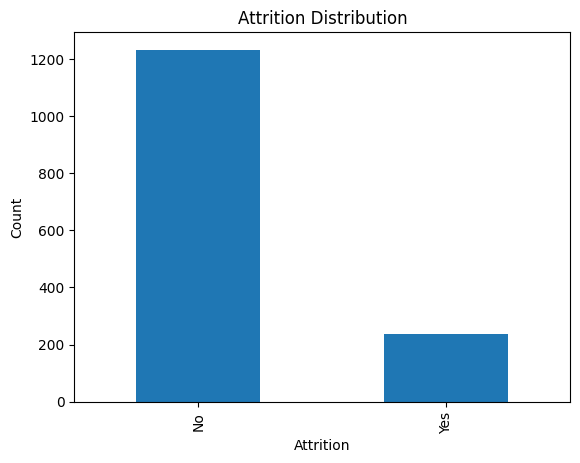

In [9]:
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

**Key Insight:**
The dataset is imbalanced — approximately 84% of employees stay while only 16% leave. This means attrition is not the majority case, and a naive model could achieve high accuracy simply by predicting everyone stays. Model evaluation will need to focus on recall and precision for the attrition class to ensure we actually detect employees at risk.

**Data Quality Summary:**

- No missing values — preprocessing is straightforward
- No duplicate records
- Mix of numerical and categorical features requiring appropriate encoding
- Target variable (Attrition) is clearly defined but imbalanced (84:16)
- Some features contain constant values (e.g., EmployeeCount, Over18, StandardHours) and will be removed during preprocessing

### 4.3 Data Definition

The full dataset contains 35 features. The following are most relevant to this analysis, selected based on their relationship to employee behavior, career progression, workload, and compensation:

- **Attrition**: Target variable — whether an employee left the company (Yes / No)
- **Age**: Employee age
- **BusinessTravel**: Frequency of business travel
- **Department**: Employee department within the organization
- **JobRole**: Specific job role of the employee
- **JobLevel**: Level of the job within the organization hierarchy
- **MonthlyIncome**: Monthly salary of the employee
- **OverTime**: Whether the employee works overtime
- **StockOptionLevel**: Level of stock ownership as part of compensation
- **TotalWorkingYears**: Total years of work experience
- **YearsAtCompany**: Number of years the employee has worked at the company
- **YearsInCurrentRole**: Years in current role
- **YearsSinceLastPromotion**: Years since last promotion
- **WorkLifeBalance**: Level of work-life balance reported by the employee
- **JobSatisfaction**: Employee satisfaction with their job
- **EnvironmentSatisfaction**: Satisfaction with the work environment

Features not listed here (e.g., DailyRate, HourlyRate, MonthlyRate, EmployeeNumber) are either non-informative, identifiers, or not directly relevant to the analysis scope. They will be assessed during preprocessing.

## **5. Data Cleaning & Preprocessing**

This section prepares the dataset for analysis by checking data quality issues and removing non-informative features. Since this is a relatively clean dataset, the focus is on validation and documentation rather than heavy transformation.

### 5.1 Check Unique Values per Column

Before cleaning, we inspect the number of unique values in each column to identify constant or low-variance features.

In [10]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


**Observation:**
Three columns contain only a single unique value:
- `EmployeeCount` → always 1
- `Over18` → always "Y"
- `StandardHours` → always 80

These features carry no analytical value and will be removed.

Additionally, `EmployeeNumber` is a unique identifier (1,470 unique values for 1,470 rows) — it does not represent an employee attribute and should also be dropped.


### 5.2 Drop Non-Informative Columns

In [11]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

df = df.drop(columns=drop_cols)

df.shape

(1470, 31)

Rationale:
- `EmployeeCount`, `Over18`, `StandardHours` — constant values, zero variance, no predictive or analytical power
- `EmployeeNumber` — row identifier, not a meaningful feature

### 5.3 Check & Remove Duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

**Observation:**
No duplicate records found. The dataset retains all 1,470 rows.

### 5.4 Check Missing Values

In [14]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


**Observation:**
No missing values in any column. No imputation is required.

### 5.5 Check Typos in Categorical Columns

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")
    print()

Attrition: ['Yes' 'No']

BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department: ['Sales' 'Research & Development' 'Human Resources']

EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender: ['Female' 'Male']

JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus: ['Single' 'Married' 'Divorced']

OverTime: ['Yes' 'No']



**Observation:**
All categorical columns have consistent and expected values — no typos, inconsistent casing, or unexpected entries detected. For example:
- `Attrition`: Yes, No
- `OverTime`: Yes, No
- `Department`: Sales, Research & Development, Human Resources
- `BusinessTravel`: Travel_Rarely, Travel_Frequently, Non-Travel

No string cleaning is needed beyond the target variable encoding below.

### 5.6 Encode Target Variable

The target variable `Attrition` is converted from string to binary format for modeling.

In [16]:
df['Attrition'] = df['Attrition'].astype(str).str.strip().str.title()
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [17]:
df['Attrition'].value_counts(dropna=False)

,count
Attrition,
0,1233
1,237


**Observation:**
Target variable successfully encoded — 0 = Stay, 1 = Attrition. No null values introduced during mapping.

### 5.7 Verify Data Types

In [18]:
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object


**Observation:**
All data types are appropriate for analysis:
- Numerical features are stored as `int64`
- Categorical features are stored as `object` / `string`
- No date/time columns exist in this dataset (cross-sectional snapshot), so no datetime conversion is needed

### 5.8 Clean Column Names

In [19]:
df.columns = df.columns.str.strip()

### 5.9 Outlier Assessment

In [20]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Observation:
Some features show wide ranges — for example, `MonthlyIncome` ranges from 1,009 to 19,999 and `TotalWorkingYears` from 0 to 40. However, these are **not treated as outliers** for the following reasons:

1. **Domain context** — The income range reflects the natural salary spread across JobLevel 1 to 5. Similarly, working years from 0 to 40 represent fresh graduates through senior employees. These are real and meaningful data points, not errors.
2. **Model choice** — We use Logistic Regression, which is not distance-based. Unlike KNN or SVM, it is not disproportionately affected by extreme values.
3. **Analytical value** — Removing extreme values would eliminate the very profiles we want to study (e.g., junior low-salary employees who may have the highest attrition risk).

Outliers are acknowledged but deliberately retained.

### 5.10 Final Shape

In [21]:
df.shape

(1470, 31)

In [22]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


### Data Cleaning Summary

In [23]:
cleaning_summary = pd.DataFrame({
    'Check': [
        'Constant-value columns', 'Identifier column', 'Duplicate records',
        'Missing values', 'Typos in categoricals', 'Target encoding',
        'Data types', 'Date/time columns', 'Merge columns', 'Outliers'
    ],
    'Result': [
        'EmployeeCount, Over18, StandardHours', 'EmployeeNumber', 'None found',
        'None found', 'None found', 'Attrition (Yes/No → 1/0)',
        'All appropriate', 'Not applicable (cross-sectional)', 'Not applicable',
        'Present but contextually valid'
    ],
    'Action': [
        'Dropped', 'Dropped', 'No action needed',
        'No action needed', 'No action needed', 'Encoded',
        'No conversion needed', 'N/A', 'N/A',
        'Retained with reasoning'
    ]
})

cleaning_summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Check,Result,Action
Constant-value columns,"EmployeeCount, Over18, StandardHours",Dropped
Identifier column,EmployeeNumber,Dropped
Duplicate records,None found,No action needed
Missing values,None found,No action needed
Typos in categoricals,None found,No action needed
Target encoding,Attrition (Yes/No → 1/0),Encoded
Data types,All appropriate,No conversion needed
Date/time columns,Not applicable (cross-sectional),N/A
Merge columns,Not applicable,N/A
Outliers,Present but contextually valid,Retained with reasoning


The dataset is now clean and ready for exploratory analysis. Final shape: **1,470 rows × 31 columns**.

======================== baru sampai sini editnya

## **6. Exploratory Data Analysis**



This analysis focuses on identifying the key drivers of attrition using the variables most relevant to our business context. Rather than exploring all 31 features, we focus on 7–8 high-impact variables selected based on HR domain knowledge and validated through attrition rate analysis.

Variables are selected based on three well-documented HR drivers of attrition: **workload** (overtime exposure), **compensation** (salary level, stock options), and **career stage** (experience, tenure, job level). These dimensions are consistently cited in HR literature as primary factors influencing voluntary turnover.

The selection is validated in this analysis by comparing attrition rates across groups within each variable — where meaningful differences in attrition rate between groups indicate that the variable is relevant to the problem. Variables that do not show meaningful group-level differences (e.g., DistanceFromHome, NumCompaniesWorked) are excluded to maintain analytical focus.

In [24]:
variable_selection = pd.DataFrame({
    'Driver Category': ['Workload', 'Career Stage', 'Compensation', 'Supporting'],
    'Variables': [
        'OverTime',
        'TotalWorkingYears, YearsAtCompany, JobLevel',
        'MonthlyIncome, StockOptionLevel',
        'Age'
    ],
    'Selection Basis': [
        'Workload imbalance is a known driver of burnout and turnover',
        'Early-career employees are at higher flight risk',
        'Pay competitiveness directly affects retention',
        'Demographic proxy — correlates with career stage and mobility'
    ]
})

variable_selection.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Driver Category,Variables,Selection Basis
Workload,OverTime,Workload imbalance is a known driver of burnout and turnover
Career Stage,"TotalWorkingYears, YearsAtCompany, JobLevel",Early-career employees are at higher flight risk
Compensation,"MonthlyIncome, StockOptionLevel",Pay competitiveness directly affects retention
Supporting,Age,Demographic proxy — correlates with career stage and mobility


In [25]:
# Prepare data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df['OverTimeFlag'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['SalaryGroup'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
df['ExperienceGroup'] = pd.cut(df['TotalWorkingYears'], bins=[-1, 2, 5, 10, 20, 40], labels=['0-2', '3-5', '6-10', '11-20', '21+'])
df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=[-1, 1, 3, 5, 10, 40], labels=['0-1', '2-3', '4-5', '6-10', '11+'])

# Color scheme
COLOR_STAY = '#5DADE2'     # blue — stay / stable
COLOR_LEAVE = '#F39C12'    # orange — attrition / alert
COLOR_BAR = '#5DADE2'      # blue — general comparison bars
COLOR_ALERT = '#E74C3C'    # red — highlight high-risk

### 6.1 Attrition Overview

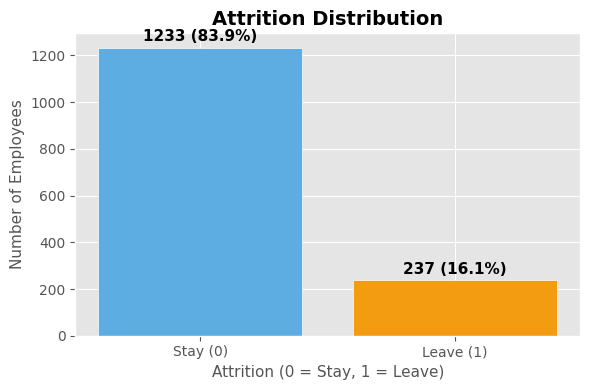

In [26]:
counts = df['Attrition'].value_counts()
total = counts.sum()

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(['Stay (0)', 'Leave (1)'], counts.values, color=[COLOR_STAY, COLOR_LEAVE], edgecolor='white')

for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val} ({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Attrition Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Attrition (0 = Stay, 1 = Leave)', fontsize=11)
ax.set_ylabel('Number of Employees', fontsize=11)
plt.tight_layout()
plt.show()

**Insight:**
Out of 1,470 employees, 237 (16.1%) have left the organization while 1,233 (83.9%) remain. The attrition rate exceeds the best-practice benchmark of ≤ 10% for tech corporates.

**Business Implication:**
At this rate, the organization is losing roughly 1 in 6 employees. Based on SHRM benchmarks (50–200% of annual salary per replacement), this level of turnover represents a significant recurring cost. The following sections identify where this attrition concentrates.


### 6.2 Workload — Overtime

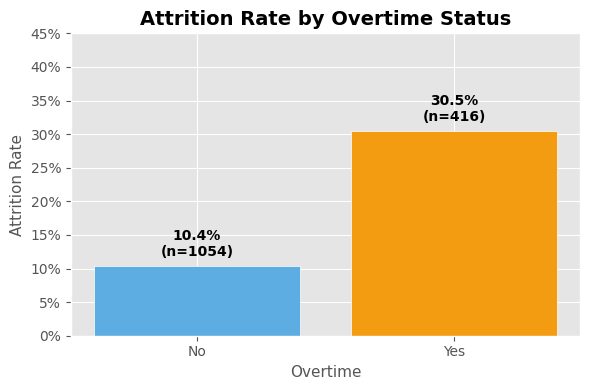

In [27]:
attrition_ot = df.groupby('OverTime')['Attrition'].mean()
counts_ot = df['OverTime'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(attrition_ot.index, attrition_ot.values, color=[COLOR_STAY, COLOR_LEAVE], edgecolor='white')

for bar, rate, grp in zip(bars, attrition_ot.values, attrition_ot.index):
    n = counts_ot[grp]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Attrition Rate by Overtime Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Overtime', fontsize=11)
ax.set_ylabel('Attrition Rate', fontsize=11)
ax.set_ylim(0, 0.45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

**Insight:**
Employees who work overtime have an attrition rate of **30.5%** — nearly **3× higher** than those who do not (10.4%). Overtime affects 416 employees (28.3% of the workforce).

**Business Implication:**
Overtime is the single strongest predictor of attrition in this dataset. This is not just a workload issue — it signals systemic capacity problems. When nearly 1 in 3 overtime workers leaves, the organization is effectively burning through the employees it relies on most during peak demand.

**Next Step:**
Investigate whether overtime interacts with compensation to create compounding risk (Section 6.5).


### 6.3 Career Stage — Experience, Tenure & Job Level

This section examines attrition across three dimensions of career stage: total work experience, tenure at the company, and organizational level.

In [28]:
descriptive_stats = pd.DataFrame({
    'Metric': ['TotalWorkingYears', 'YearsAtCompany', 'Age'],
    'Stay (mean)': [11.9, 7.4, 37.6],
    'Stay (median)': [10.0, 6.0, 36.0],
    'Leave (mean)': [8.2, 5.1, 33.6],
    'Leave (median)': [7.0, 3.0, 32.0]
})

descriptive_stats.style.set_properties(**{'text-align': 'left'}).format(precision=1).hide(axis='index')

Metric,Stay (mean),Stay (median),Leave (mean),Leave (median)
TotalWorkingYears,11.9,10.0,8.2,7.0
YearsAtCompany,7.4,6.0,5.1,3.0
Age,37.6,36.0,33.6,32.0


Employees who leave are on average younger, less experienced, and have shorter tenure — consistent with early-career flight risk.

/tmp/ipykernel_8482/4261986805.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_attr = df.groupby('ExperienceGroup')['Attrition'].mean()
/tmp/ipykernel_8482/4261986805.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attr = df.groupby('TenureGroup')['Attrition'].mean()


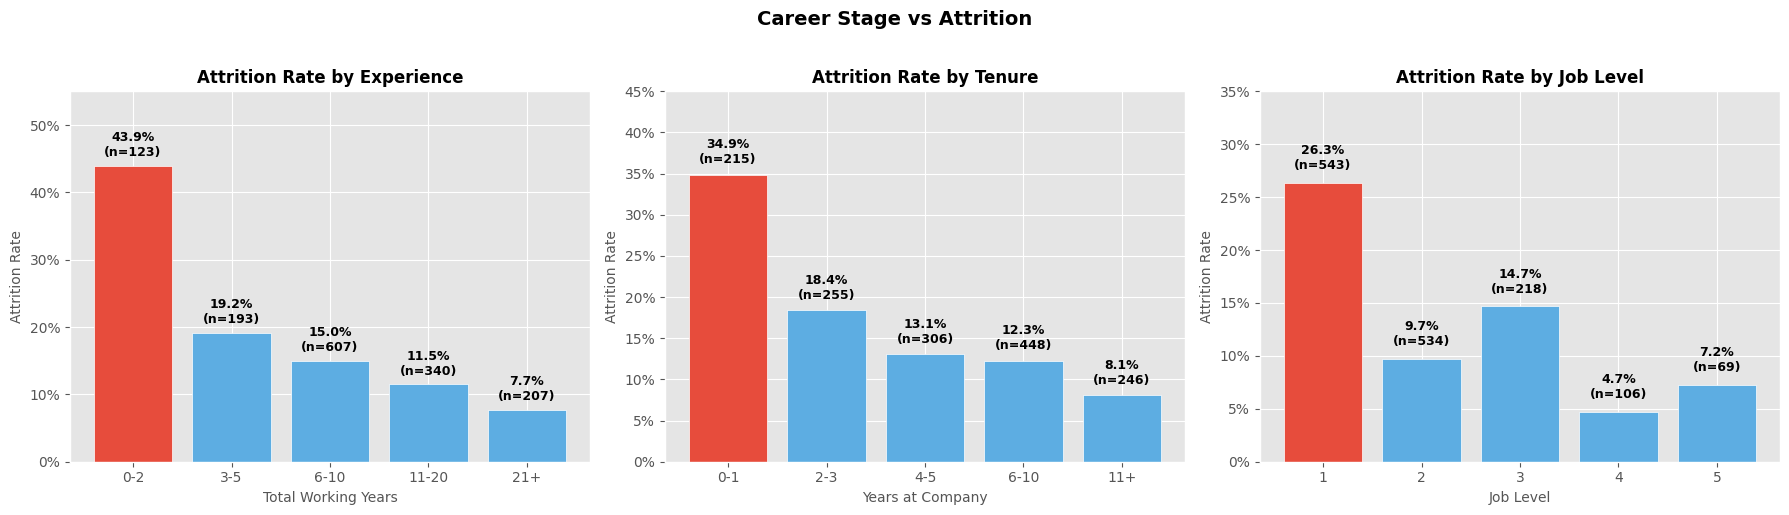

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Experience Group ---
exp_attr = df.groupby('ExperienceGroup')['Attrition'].mean()
counts_exp = df['ExperienceGroup'].value_counts().sort_index()

colors_exp = [COLOR_ALERT if v > 0.20 else COLOR_BAR for v in exp_attr.values]
bars = axes[0].bar(exp_attr.index, exp_attr.values, color=colors_exp, edgecolor='white')
for bar, rate, grp in zip(bars, exp_attr.values, exp_attr.index):
    n = counts_exp[grp]
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Attrition Rate by Experience', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Working Years', fontsize=10)
axes[0].set_ylabel('Attrition Rate', fontsize=10)
axes[0].set_ylim(0, 0.55)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# --- Tenure Group ---
tenure_attr = df.groupby('TenureGroup')['Attrition'].mean()
counts_tenure = df['TenureGroup'].value_counts().sort_index()

colors_ten = [COLOR_ALERT if v > 0.20 else COLOR_BAR for v in tenure_attr.values]
bars = axes[1].bar(tenure_attr.index, tenure_attr.values, color=colors_ten, edgecolor='white')
for bar, rate, grp in zip(bars, tenure_attr.values, tenure_attr.index):
    n = counts_tenure[grp]
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Attrition Rate by Tenure', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years at Company', fontsize=10)
axes[1].set_ylabel('Attrition Rate', fontsize=10)
axes[1].set_ylim(0, 0.45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# --- Job Level ---
jl_attr = df.groupby('JobLevel')['Attrition'].mean()
counts_jl = df['JobLevel'].value_counts().sort_index()

colors_jl = [COLOR_ALERT if v > 0.20 else COLOR_BAR for v in jl_attr.values]
bars = axes[2].bar(jl_attr.index.astype(str), jl_attr.values, color=colors_jl, edgecolor='white')
for bar, rate, lvl in zip(bars, jl_attr.values, jl_attr.index):
    n = counts_jl[lvl]
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_title('Attrition Rate by Job Level', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Job Level', fontsize=10)
axes[2].set_ylabel('Attrition Rate', fontsize=10)
axes[2].set_ylim(0, 0.35)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Career Stage vs Attrition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**
Attrition follows a clear **early-career pattern** across all three dimensions:
- **Experience 0–2 years**: 43.9% attrition — nearly half of this group leaves
- **Tenure 0–1 year**: 34.9% attrition — the first year is the highest-risk window
- **Job Level 1**: 26.3% attrition — entry-level employees are 3–5× more likely to leave than senior levels

The pattern is consistent: attrition rate decreases as employees gain experience, tenure, and organizational level. This is not random churn — it reflects a systemic retention gap in the early career stage.

**Business Implication:**
The organization is investing in hiring and onboarding employees who leave before delivering full value. When 35–44% of early-stage employees leave, the company is repeatedly paying onboarding costs without capturing the return.

**Next Step:**
Assess whether compensation is competitive enough to retain early-career employees (Section 6.4).


### 6.4 Compensation — Monthly Income

/tmp/ipykernel_8482/2069252127.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_attr = df.groupby('SalaryGroup')['Attrition'].mean()


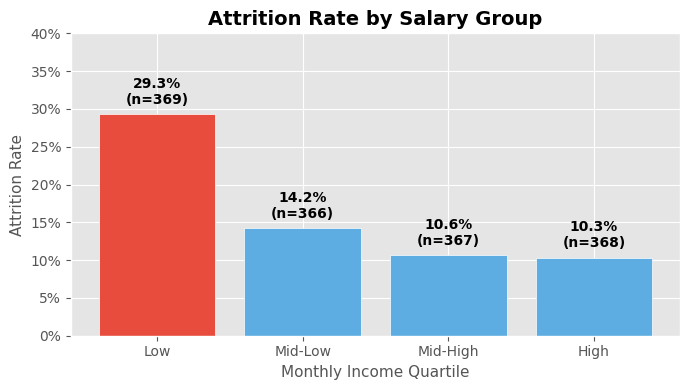

In [30]:
salary_attr = df.groupby('SalaryGroup')['Attrition'].mean()
counts_salary = df['SalaryGroup'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))

colors_sal = [COLOR_ALERT if v > 0.20 else COLOR_BAR for v in salary_attr.values]
bars = ax.bar(salary_attr.index, salary_attr.values, color=colors_sal, edgecolor='white')

for bar, rate, grp in zip(bars, salary_attr.values, salary_attr.index):
    n = counts_salary[grp]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Attrition Rate by Salary Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Income Quartile', fontsize=11)
ax.set_ylabel('Attrition Rate', fontsize=11)
ax.set_ylim(0, 0.40)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

/tmp/ipykernel_8482/4059871016.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([stay_income, leave_income], labels=['Stay', 'Leave'],


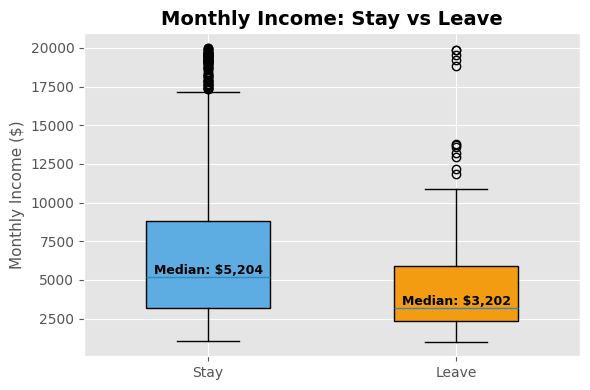

In [31]:
# Stay vs Leave income comparison
fig, ax = plt.subplots(figsize=(6, 4))

stay_income = df[df['Attrition'] == 0]['MonthlyIncome']
leave_income = df[df['Attrition'] == 1]['MonthlyIncome']

bp = ax.boxplot([stay_income, leave_income], labels=['Stay', 'Leave'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor(COLOR_STAY)
bp['boxes'][1].set_facecolor(COLOR_LEAVE)

ax.text(1, stay_income.median(), f'Median: ${stay_income.median():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.text(2, leave_income.median(), f'Median: ${leave_income.median():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Monthly Income: Stay vs Leave', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly Income ($)', fontsize=11)
plt.tight_layout()
plt.show()

**Insight:**
Attrition rate in the lowest salary quartile is **29.3%** — roughly **3× higher** than the top two quartiles (~10%). Employees who leave have a median income of $3,202 vs $5,204 for those who stay — a **38% gap**.

**Business Implication:**
Low compensation is a significant flight risk factor. Employees in the bottom quartile are likely comparing their salary to market alternatives. The question is not whether to raise salaries, but *for whom* the raise would have the highest retention ROI.


### 6.5 Combined Risk — Workload x Compensation

This section examines the interaction between the two strongest drivers: overtime and salary level.

/tmp/ipykernel_8482/1832988975.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo_attr = df.groupby(['SalaryGroup', 'OverTime'])['Attrition'].mean().unstack()
/tmp/ipykernel_8482/1832988975.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combo_count = df.groupby(['SalaryGroup', 'OverTime'])['Attrition'].count().unstack()


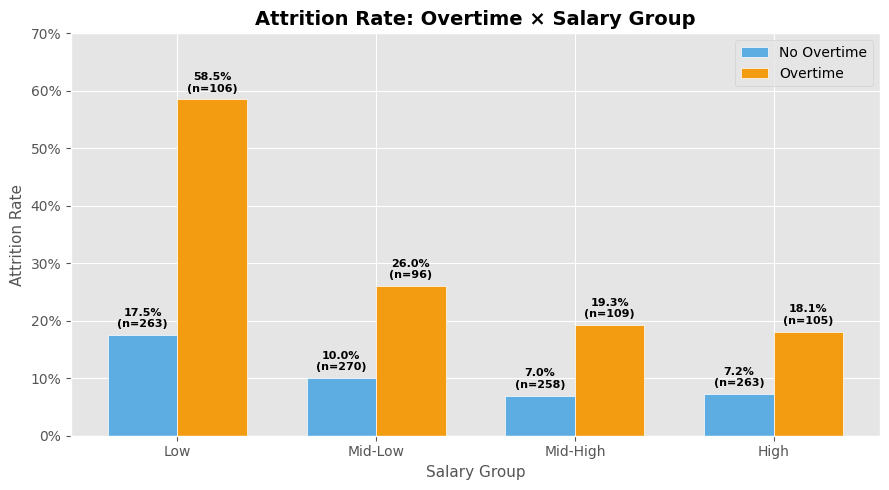

In [32]:
combo_attr = df.groupby(['SalaryGroup', 'OverTime'])['Attrition'].mean().unstack()
combo_count = df.groupby(['SalaryGroup', 'OverTime'])['Attrition'].count().unstack()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(combo_attr.index))
width = 0.35

bars_no = ax.bar(x - width/2, combo_attr['No'], width, label='No Overtime',
                 color=COLOR_STAY, edgecolor='white')
bars_yes = ax.bar(x + width/2, combo_attr['Yes'], width, label='Overtime',
                  color=COLOR_LEAVE, edgecolor='white')

for bar, rate, grp in zip(bars_no, combo_attr['No'], combo_attr.index):
    n = combo_count.loc[grp, 'No']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar, rate, grp in zip(bars_yes, combo_attr['Yes'], combo_attr.index):
    n = combo_count.loc[grp, 'Yes']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Attrition Rate: Overtime × Salary Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Salary Group', fontsize=11)
ax.set_ylabel('Attrition Rate', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(combo_attr.index)
ax.set_ylim(0, 0.70)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Insight:**
The interaction effect is dramatic. Among low-salary employees who also work overtime, the attrition rate reaches **58.5%** — meaning more than half of this group leaves. This is **3.3× higher** than low-salary employees without overtime (17.5%) and **5.6× higher** than the overall attrition rate (16.1%).

Even in higher salary groups, overtime roughly doubles the attrition rate (7.2% → 18.1% in the High group).

**Business Implication:**
This is the most critical finding in the dataset. Low salary + overtime is not just a risk factor — it is effectively a **departure trigger**. These 106 employees represent the highest-priority intervention group. Addressing either overtime or compensation alone may not be sufficient; the combination is what drives the extreme attrition. Intervention design should target this intersection specifically.


### 6.6 Supporting Factors — Age & Stock Option

/tmp/ipykernel_8482/1873615856.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attr = df.groupby('AgeGroup')['Attrition'].mean()


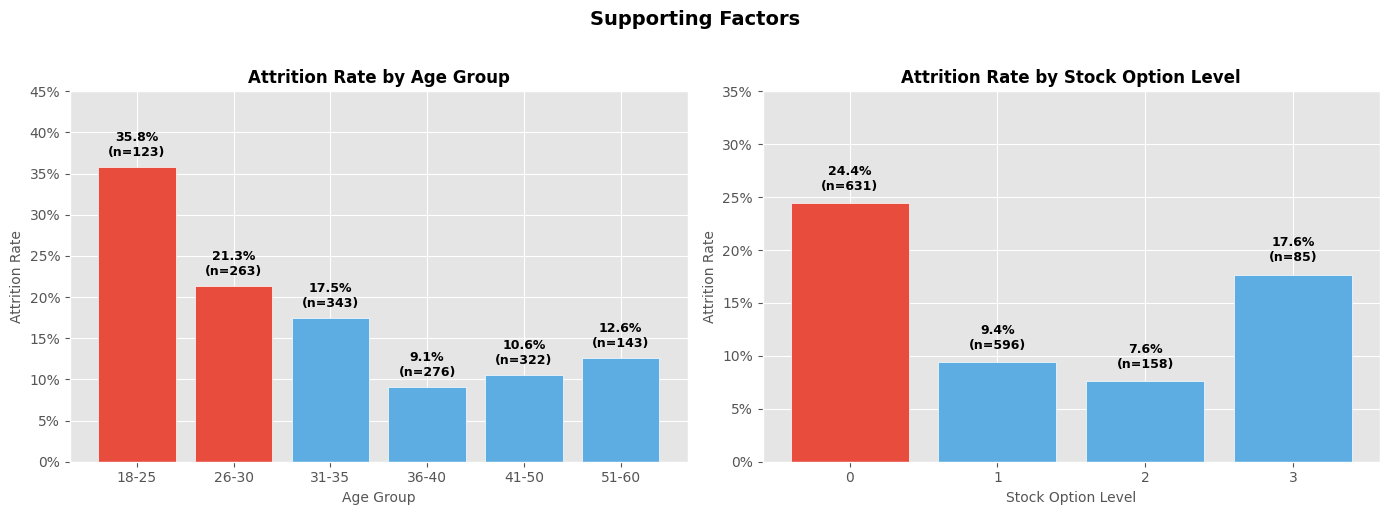

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Age Group ---
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 30, 35, 40, 50, 61],
                        labels=['18-25', '26-30', '31-35', '36-40', '41-50', '51-60'])
age_attr = df.groupby('AgeGroup')['Attrition'].mean()
counts_age = df['AgeGroup'].value_counts().sort_index()

colors_age = [COLOR_ALERT if v > 0.20 else COLOR_BAR for v in age_attr.values]
bars = axes[0].bar(age_attr.index, age_attr.values, color=colors_age, edgecolor='white')
for bar, rate, grp in zip(bars, age_attr.values, age_attr.index):
    n = counts_age[grp]
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Attrition Rate by Age Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=10)
axes[0].set_ylabel('Attrition Rate', fontsize=10)
axes[0].set_ylim(0, 0.45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# --- Stock Option Level ---
so_attr = df.groupby('StockOptionLevel')['Attrition'].mean()
counts_so = df['StockOptionLevel'].value_counts().sort_index()

colors_so = [COLOR_ALERT if v > 0.20 else COLOR_BAR for v in so_attr.values]
bars = axes[1].bar(so_attr.index.astype(str), so_attr.values, color=colors_so, edgecolor='white')
for bar, rate, lvl in zip(bars, so_attr.values, so_attr.index):
    n = counts_so[lvl]
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}\n(n={n})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Attrition Rate by Stock Option Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Stock Option Level', fontsize=10)
axes[1].set_ylabel('Attrition Rate', fontsize=10)
axes[1].set_ylim(0, 0.35)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.suptitle('Supporting Factors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight:**
- **Age**: Employees aged 18–25 have the highest attrition at 35.8%, decreasing sharply after age 35. This aligns with the career stage pattern — younger employees are more mobile and have lower switching costs.
- **Stock Option**: Employees with no stock options (Level 0) show 24.4% attrition — roughly 2.5× higher than those with Level 1–2 options. However, Level 3 shows a slight increase (17.6%), possibly due to small sample size (n=85).

**Business Implication:**
Age reinforces the early-career risk pattern but is not directly actionable. Stock options, however, are actionable — they represent a long-term financial incentive that ties employees to the organization. The data suggests that even a modest stock option (Level 1) reduces attrition from 24.4% to 9.4%. This could be a cost-effective retention lever, particularly for early-career, low-salary employees.


### 6.7 Statistical Validation (Chi-Square Test)

The patterns observed in the previous sections are visually clear, but we need to confirm that these differences are **statistically significant** — not just artifacts of sample variation. The Chi-Square test of independence evaluates whether the relationship between each variable and attrition is statistically meaningful.


In [34]:
from scipy.stats import chi2_contingency

chi_vars = {
    'OverTime': df['OverTime'],
    'SalaryGroup': df['SalaryGroup'],
    'ExperienceGroup': df['ExperienceGroup'],
    'TenureGroup': df['TenureGroup'],
    'JobLevel': df['JobLevel'],
    'StockOptionLevel': df['StockOptionLevel']
}

chi_results = []
for name, col in chi_vars.items():
    ct = pd.crosstab(col, df['Attrition'])
    chi2, p, dof, expected = chi2_contingency(ct)
    chi_results.append({
        'Variable': name,
        'Chi-Square': round(chi2, 2),
        'p-value': f'{p:.2e}',
        'Significant (p < 0.05)': '✓ Yes' if p < 0.05 else '✗ No'
    })

chi_df = pd.DataFrame(chi_results)
chi_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Variable,Chi-Square,p-value,Significant (p < 0.05)
OverTime,87.560000,8.16e-21,✓ Yes
SalaryGroup,65.490000,3.95e-14,✓ Yes
ExperienceGroup,88.320000,3.00e-18,✓ Yes
TenureGroup,75.590000,1.49e-15,✓ Yes
JobLevel,72.530000,6.63e-15,✓ Yes
StockOptionLevel,60.600000,4.38e-13,✓ Yes


**Interpretation:**
All six variables show a statistically significant relationship with attrition (p < 0.05). This means:
- The attrition rate differences we observed across groups (e.g., OT 30.5% vs Non-OT 10.4%) are **not due to chance** — they reflect real patterns in the data
- OverTime and ExperienceGroup show the highest chi-square values, confirming they have the strongest association with attrition
- These results validate that our variable selection is statistically sound, in addition to being domain-relevant

**Note:** Chi-square confirms *association*, not *causation*. These variables are significantly related to attrition, but the test does not tell us the direction or magnitude of the effect — that was established through the attrition rate analysis in the previous sections.


### 6.8 EDA Summary

The exploratory analysis reveals that attrition at this organization is not random — it is concentrated within specific, identifiable employee segments driven by three core factors:

**Overtime** is the single strongest predictor. Employees who work overtime are 3× more likely to leave (30.5% vs 10.4%). This suggests systemic workload imbalance, not individual choice. **Compensation** is the second driver — low-salary employees have a 29.3% attrition rate, and the median income of departing employees is 38% lower than those who stay. **Career stage** is the third dimension — early-career employees (0–2 years experience, 0–1 year tenure, Job Level 1) show attrition rates of 26–44%, indicating a critical retention gap in the first 1–2 years of employment.

The most critical finding is the **interaction between overtime and low salary**: 58.5% of employees in this combined group leave — making it effectively a departure trigger rather than just a risk factor. This group of ~106 employees should be the highest priority for intervention.

These three drivers — workload, compensation, and career stage — account for the majority of explainable attrition and will form the basis for feature engineering, modeling, and intervention design in the following sections.


## **7. Feature Engineering**


Feature engineering translates raw data into model-ready inputs based on the key drivers identified during EDA. The objective is to create features that are both **interpretable** (can be explained to stakeholders) and **actionable** (linked to interventions the company can take).

This section distinguishes between three types of features:
- **Encoding** — converting existing categorical variables into numerical format
- **Binning** — grouping continuous variables into meaningful segments (used for EDA, but raw values are preferred for modeling)
- **New features** — creating variables that do not exist in the raw data, based on domain insight

### 7.1 Encoding — Overtime Flag

In [35]:
df['OverTimeFlag'] = df['OverTime'].map({'Yes': 1, 'No': 0})

**What:** Converts OverTime (Yes/No) into binary (1/0).

**Why:** OverTime is categorical — the model needs it in numerical format. This is a direct encoding, not a transformation. The original meaning is fully preserved.

**EDA Reference:** Employees with OverTime = Yes show 30.5% attrition vs 10.4% for No (Section 6.2).

### 7.2 Binning — Experience Group

In [36]:
df['ExperienceGroup'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[-1, 2, 5, 10, 20, 40],
    labels=['0-2', '3-5', '6-10', '11-20', '21+']
)

**What:** Groups total work experience into career stages.

**Why:** Binning makes it easier to see patterns in EDA (e.g., "0–2 years = 43.9% attrition"). However, for modeling, we will use the raw `TotalWorkingYears` value to preserve granularity — the model benefits from continuous input rather than discrete bins.

**Bin Logic:**
- 0–2: Entry-level, highest risk window
- 3–5: Early career, still exploring
- 6–10: Settling phase
- 11–20: Established
- 21+: Senior/long-tenure


### 7.3 Binning — Tenure Group

In [37]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 1, 3, 5, 10, 40],
    labels=['0-1', '2-3', '4-5', '6-10', '11+']
)

**What:** Groups company tenure into retention stages.

**Why:** Same rationale as ExperienceGroup — useful for EDA segmentation, but raw `YearsAtCompany` will be used in the model.

**EDA Reference:** Tenure 0–1 year shows 34.9% attrition — the first year is the highest-risk window (Section 6.3).


### 7.4 Binning — Salary Group

In [38]:
df['SalaryGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

**What:** Divides MonthlyIncome into quartiles.

**Why:** Quartile-based grouping allows comparison of attrition rates across salary levels. For modeling, raw `MonthlyIncome` will be used. SalaryGroup is retained because it is needed to construct the combined risk feature below.

**EDA Reference:** Low quartile shows 29.3% attrition vs ~10% in the top two quartiles (Section 6.4).

### 7.5 New Feature — Combined Risk (Overtime × Low Salary)

In [39]:
df['OverTime_LowSalary'] = (
    (df['OverTimeFlag'] == 1) & (df['SalaryGroup'] == 'Low')
).astype(int)

**What:** Binary flag — 1 if the employee works overtime AND is in the lowest salary quartile.

**Why:** This is the most important engineered feature. EDA revealed that this combination produces **58.5% attrition** — more than half of this group leaves. Neither overtime nor low salary alone fully explains this extreme rate; it is the interaction that creates the departure trigger. This feature allows the model to capture this compounding effect.

**Business Link:** This directly maps to the highest-priority intervention group identified in Section 6.5.

### 7.6 New Feature — Early Career Indicator

In [40]:
df['EarlyCareer'] = (
    (df['ExperienceGroup'] == '0-2') |
    (df['TenureGroup'] == '0-1')
).astype(int)

**What:** Binary flag — 1 if the employee has ≤ 2 years of total experience OR ≤ 1 year of company tenure.

**Why:** Early-career employees show consistently elevated attrition across multiple dimensions (experience, tenure, job level). Rather than relying on three separate variables to capture this pattern, a single composite flag identifies employees in the high-risk early stage regardless of which specific dimension triggers it.

**EDA Reference:** Experience 0–2 = 43.9%, Tenure 0–1 = 34.9%, Job Level 1 = 26.3% attrition (Section 6.3).


### 7.7 Existing Features — No Transformation Needed

The following raw features will be used directly in modeling without transformation:

In [41]:
# These features are already in usable format
# JobLevel — ordinal (1-5), represents organizational hierarchy
# StockOptionLevel — ordinal (0-3), represents compensation incentive
# Age — continuous, supporting demographic variable
# MonthlyIncome — continuous, used as raw value in model
# TotalWorkingYears — continuous, used as raw value in model
# YearsAtCompany — continuous, used as raw value in model

**Why no transformation?**
- `JobLevel` and `StockOptionLevel` are ordinal with meaningful order — encoding preserves the scale
- Continuous variables (Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany) are better kept raw for Logistic Regression to capture linear relationships

### 7.8 Verify Engineered Features

In [42]:
df[['OverTimeFlag', 'ExperienceGroup', 'TenureGroup', 'SalaryGroup',
    'OverTime_LowSalary', 'EarlyCareer']].head(10)

,OverTimeFlag,ExperienceGroup,TenureGroup,SalaryGroup,OverTime_LowSalary,EarlyCareer
0,1,6-10,6-10,Mid-High,0,0
1,0,6-10,6-10,Mid-High,0,0
2,1,6-10,0-1,Low,1,1
3,1,6-10,6-10,Low,1,0
4,0,6-10,2-3,Mid-Low,0,0
5,0,6-10,6-10,Mid-Low,0,0
6,1,11-20,0-1,Low,1,1
7,0,0-2,0-1,Low,0,1
8,0,6-10,6-10,High,0,0
9,0,11-20,6-10,Mid-High,0,0


In [43]:
print(f"OverTime_LowSalary = 1: {df['OverTime_LowSalary'].sum()} employees")
print(f"EarlyCareer = 1: {df['EarlyCareer'].sum()} employees")

OverTime_LowSalary = 1: 106 employees
EarlyCareer = 1: 242 employees


### 7.9 Feature Engineering Summary

In [44]:
fe_summary = pd.DataFrame({
    'Feature': [
        'OverTimeFlag', 'ExperienceGroup', 'TenureGroup', 'SalaryGroup',
        'OverTime_LowSalary', 'EarlyCareer'
    ],
    'Type': [
        'Encoding', 'Binning (EDA only)', 'Binning (EDA only)', 'Binning (EDA + interaction)',
        'New — Interaction', 'New — Composite'
    ],
    'Used in Model': [
        'Yes', 'No (raw TotalWorkingYears used)', 'No (raw YearsAtCompany used)',
        'No (raw MonthlyIncome used)', 'Yes', 'Yes'
    ],
    'Rationale': [
        'Strongest single driver of attrition (30.5% vs 10.4%)',
        'EDA segmentation — early career risk pattern',
        'EDA segmentation — first-year retention gap',
        'EDA segmentation + needed for interaction feature',
        'Captures 58.5% attrition in OT + low salary group',
        'Flags early-stage employees across multiple dimensions'
    ]
})

fe_summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Feature,Type,Used in Model,Rationale
OverTimeFlag,Encoding,Yes,Strongest single driver of attrition (30.5% vs 10.4%)
ExperienceGroup,Binning (EDA only),No (raw TotalWorkingYears used),EDA segmentation — early career risk pattern
TenureGroup,Binning (EDA only),No (raw YearsAtCompany used),EDA segmentation — first-year retention gap
SalaryGroup,Binning (EDA + interaction),No (raw MonthlyIncome used),EDA segmentation + needed for interaction feature
OverTime_LowSalary,New — Interaction,Yes,Captures 58.5% attrition in OT + low salary group
EarlyCareer,New — Composite,Yes,Flags early-stage employees across multiple dimensions


Features were designed based on **business relevance and EDA findings**, not purely statistical transformations. The distinction between EDA-only features (binning) and model features (encoding + new) is intentional — binning helps us see patterns, but the model benefits from raw continuous values to capture finer-grained relationships.

## **8. Modeling**


The objective of modeling is not only to predict attrition, but to identify interpretable and actionable HR drivers. The model should support business decision-making by flagging high-risk employees early enough for the organization to intervene.

**Model Selection Strategy:**
We train and compare two model types:
- **Logistic Regression** — interpretable, coefficients map directly to business insights
- **Random Forest** — more flexible, captures non-linear patterns, provides feature importance

Both models are evaluated not just on accuracy, but on their ability to **detect attrition cases** (recall) and their **overall discrimination ability** (ROC-AUC, PR-AUC). The final model is selected based on both performance and business fit.

### 8.1 Feature Selection for Modeling

Based on findings from EDA (Section 6) and Feature Engineering (Section 7), the model uses a combination of raw numerical features and engineered features:


In [45]:
model_features = [
    # Engineered features
    'OverTimeFlag',           # Binary — strongest single driver
    'OverTime_LowSalary',     # Interaction — 58.5% attrition group
    'EarlyCareer',            # Composite risk flag

    # Raw numerical features
    'JobLevel',               # Ordinal 1-5
    'MonthlyIncome',          # Continuous
    'TotalWorkingYears',      # Continuous
    'YearsAtCompany',         # Continuous
    'StockOptionLevel',       # Ordinal 0-3
    'Age'                     # Continuous
]

X = df[model_features].copy()
y = df['Attrition'].copy()

X.head()

,OverTimeFlag,OverTime_LowSalary,EarlyCareer,JobLevel,MonthlyIncome,TotalWorkingYears,YearsAtCompany,StockOptionLevel,Age
0,1,0,0,2,5993,8,6,0,41
1,0,0,0,2,5130,10,10,1,49
2,1,1,1,1,2090,7,0,0,37
3,1,1,0,1,2909,8,8,0,33
4,0,0,0,1,3468,6,2,1,27


**Why raw values instead of binned groups?**
In EDA, we used bins (ExperienceGroup, SalaryGroup) to visualize patterns. For modeling, raw continuous values are preferred because models can capture finer-grained relationships without losing information from arbitrary bin boundaries.

### 8.2 Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Attrition rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")

Train: 1176 rows | Test: 294 rows
Attrition rate — Train: 16.2% | Test: 16.0%


**Note:**`stratify=y` ensures the 84:16 attrition ratio is preserved in both train and test sets.

### 8.3 Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Why scale?**
Logistic Regression uses gradient-based optimization, and features with very different scales (e.g., MonthlyIncome: 1,000–20,000 vs OverTimeFlag: 0–1) can cause convergence issues. StandardScaler normalizes all features to mean=0, std=1. Note: Random Forest does not require scaling, but we apply it consistently for LogReg.

### 8.4 Baseline Model — Logistic Regression (Default)

We start with a default Logistic Regression to establish a performance baseline.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_baseline = LogisticRegression(max_iter=1000, random_state=42)
log_baseline.fit(X_train_scaled, y_train)

y_pred_base = log_baseline.predict(X_test_scaled)
y_prob_base = log_baseline.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline Logistic Regression ===")
print(classification_report(y_test, y_pred_base))

=== Baseline Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.62      0.21      0.32        47

    accuracy                           0.85       294
   macro avg       0.75      0.59      0.62       294
weighted avg       0.83      0.85      0.82       294



**Observation:**
The baseline model achieves ~85% accuracy, but **recall for attrition is very low (~21%)** — the model catches only about 1 in 5 employees who actually leave. It essentially learns to predict "everyone stays" because that's the majority class.

**Key Learning:**
Accuracy is misleading for imbalanced data. A model predicting "everyone stays" would get 84% accuracy and catch 0% of attrition. We need to optimize for **Recall** — what percentage of actual attrition cases does the model detect?

### 8.5 Improved Model — Balanced Logistic Regression

To address the imbalance, we retrain with `class_weight='balanced'`, which penalizes the model more for missing attrition cases.

In [49]:
log_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_balanced.predict(X_test_scaled)
y_prob_bal = log_balanced.predict_proba(X_test_scaled)[:, 1]

print("=== Balanced Logistic Regression ===")
print(classification_report(y_test, y_pred_bal))

=== Balanced Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.74      0.81       247
           1       0.31      0.62      0.41        47

    accuracy                           0.72       294
   macro avg       0.61      0.68      0.61       294
weighted avg       0.81      0.72      0.75       294



**Observation:**
Recall for attrition improves significantly (~62%) — the model now catches roughly 3 in 5 at-risk employees. This comes at the cost of lower precision (more false positives), which is an acceptable trade-off that we will justify in Section 8.9.

### 8.6 Benchmark Model — Balanced Random Forest

To test whether a more complex model can improve performance, we train a Random Forest with class balancing.

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=5,
    random_state=42
)
rf_balanced.fit(X_train, y_train)  # RF does not need scaled features

y_pred_rf = rf_balanced.predict(X_test)
y_prob_rf = rf_balanced.predict_proba(X_test)[:, 1]

print("=== Balanced Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Balanced Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       247
           1       0.34      0.43      0.38        47

    accuracy                           0.78       294
   macro avg       0.61      0.63      0.62       294
weighted avg       0.80      0.78      0.79       294



**Note**: max_depth=5 prevents overfitting — with only 1,470 rows, an unconstrained tree would memorize training data.

### 8.7 Model Comparison

In [51]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, average_precision_score

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall (Attrition)', 'Precision (Attrition)',
               'F1-Score (Attrition)', 'ROC-AUC', 'PR-AUC'],
    'LR Baseline': [
        f"{accuracy_score(y_test, y_pred_base):.1%}",
        f"{recall_score(y_test, y_pred_base):.1%}",
        f"{precision_score(y_test, y_pred_base):.1%}",
        f"{f1_score(y_test, y_pred_base):.1%}",
        f"{roc_auc_score(y_test, y_prob_base):.3f}",
        f"{average_precision_score(y_test, y_prob_base):.3f}"
    ],
    'LR Balanced': [
        f"{accuracy_score(y_test, y_pred_bal):.1%}",
        f"{recall_score(y_test, y_pred_bal):.1%}",
        f"{precision_score(y_test, y_pred_bal):.1%}",
        f"{f1_score(y_test, y_pred_bal):.1%}",
        f"{roc_auc_score(y_test, y_prob_bal):.3f}",
        f"{average_precision_score(y_test, y_prob_bal):.3f}"
    ],
    'RF Balanced': [
        f"{accuracy_score(y_test, y_pred_rf):.1%}",
        f"{recall_score(y_test, y_pred_rf):.1%}",
        f"{precision_score(y_test, y_pred_rf):.1%}",
        f"{f1_score(y_test, y_pred_rf):.1%}",
        f"{roc_auc_score(y_test, y_prob_rf):.3f}",
        f"{average_precision_score(y_test, y_prob_rf):.3f}"
    ]
})

results.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,LR Baseline,LR Balanced,RF Balanced
Accuracy,85.4%,71.8%,77.6%
Recall (Attrition),21.3%,61.7%,42.6%
Precision (Attrition),62.5%,30.9%,33.9%
F1-Score (Attrition),31.7%,41.1%,37.7%
ROC-AUC,0.740,0.742,0.749
PR-AUC,0.467,0.476,0.403


In [52]:
insight_comparison = pd.DataFrame({
    'What to look at': ['Recall', 'ROC-AUC', 'PR-AUC', 'Precision'],
    'Observation': [
        'Balanced LogReg (~62%) significantly outperforms both Baseline (~21%) and RF (~43%) in detecting attrition',
        'All three models are similar (~0.74), meaning their overall discrimination ability is comparable',
        'Balanced LogReg has the highest PR-AUC (~0.48), which is more relevant for imbalanced data than ROC-AUC',
        'Balanced LogReg trades lower precision for higher recall — an acceptable trade-off for this use case'
    ]
})

insight_comparison.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

What to look at,Observation
Recall,Balanced LogReg (~62%) significantly outperforms both Baseline (~21%) and RF (~43%) in detecting attrition
ROC-AUC,"All three models are similar (~0.74), meaning their overall discrimination ability is comparable"
PR-AUC,"Balanced LogReg has the highest PR-AUC (~0.48), which is more relevant for imbalanced data than ROC-AUC"
Precision,Balanced LogReg trades lower precision for higher recall — an acceptable trade-off for this use case


### 8.8 ROC Curve & Precision-Recall Curve

These curves provide a visual comparison of model performance across all classification thresholds — not just the default 0.5.

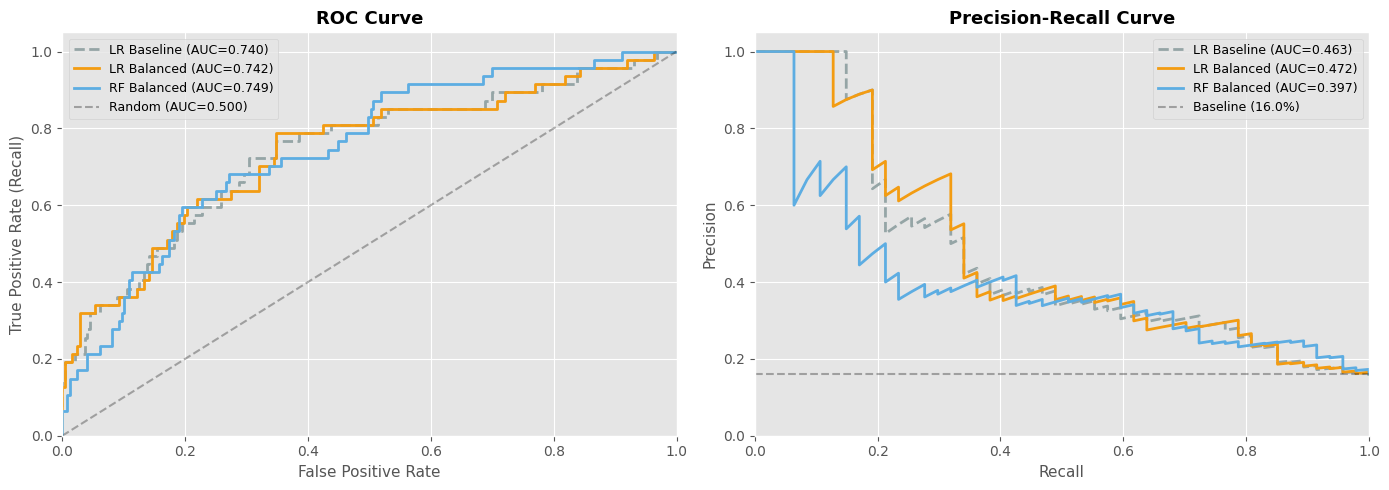

In [53]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
for name, y_prob, color, ls in [
    ('LR Baseline', y_prob_base, '#95A5A6', '--'),
    ('LR Balanced', y_prob_bal, '#F39C12', '-'),
    ('RF Balanced', y_prob_rf, '#5DADE2', '-')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                 label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# --- Precision-Recall Curve ---
for name, y_prob, color, ls in [
    ('LR Baseline', y_prob_base, '#95A5A6', '--'),
    ('LR Balanced', y_prob_bal, '#F39C12', '-'),
    ('RF Balanced', y_prob_rf, '#5DADE2', '-')
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, linestyle=ls, linewidth=2,
                 label=f'{name} (AUC={pr_auc:.3f})')

baseline_rate = y_test.mean()
axes[1].axhline(y=baseline_rate, color='k', linestyle='--', alpha=0.3,
                label=f'Baseline ({baseline_rate:.1%})')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

**How to read these curves:**
*ROC Curve (left):** Shows the trade-off between True Positive Rate (recall) and False Positive Rate. A curve closer to the top-left corner is better. AUC = 1.0 is perfect, 0.5 is random guessing. All three models perform well above random (~0.74), with Balanced LogReg slightly leading.

**PR Curve (right):** More informative than ROC for imbalanced datasets. Shows the trade-off between precision and recall. The dashed baseline represents the "predict all positive" strategy (~16% precision). A curve further from this baseline is better. Balanced LogReg shows the best performance, especially at higher recall levels — meaning it maintains better precision even when trying to catch more attrition cases.


### 8.9 Confusion Matrix — Balanced Logistic Regression

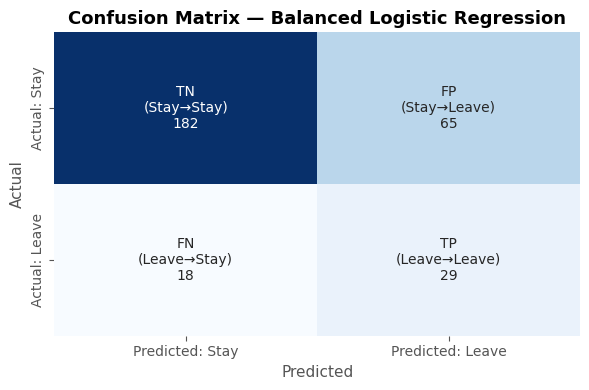

In [54]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_bal)

labels = np.array([
    [f'TN\n(Stay→Stay)\n{cm[0][0]}', f'FP\n(Stay→Leave)\n{cm[0][1]}'],
    [f'FN\n(Leave→Stay)\n{cm[1][0]}', f'TP\n(Leave→Leave)\n{cm[1][1]}']
])

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Stay', 'Predicted: Leave'],
            yticklabels=['Actual: Stay', 'Actual: Leave'], ax=ax)

ax.set_title('Confusion Matrix — Balanced Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()

### 8.10 Business Justification — Why Higher Recall Matters

The trade-off between models is ultimately a **business decision**, not just a technical one.

**Cost of a False Negative (missed attrition):**
The model fails to flag a high-risk employee → they leave → the company pays 50–200% of their annual salary in replacement costs. This is a **real financial loss**.

**Cost of a False Positive (false alarm):**
The model flags an employee who was not actually going to leave → HR reviews them, offers a check-in or small retention action → cost is minimal (a conversation).

The asymmetry is clear: **missing a departure is far more expensive than a false alarm.** Therefore, the model with higher recall — even at the cost of more false positives — is the right choice.


### 8.11 Model Selection Decision

In [55]:
selection = pd.DataFrame({
    'Criteria': [
        'Recall (catch attrition)',
        'ROC-AUC',
        'PR-AUC',
        'Interpretability',
        'Actionability (coefficients → interventions)',
        'Stakeholder trust (explainable to CEO/CHRO)'
    ],
    'LR Balanced': ['✓ Highest', '✓ Comparable', '✓ Highest', '✓ High', '✓ Yes — odds ratios', '✓ Yes'],
    'RF Balanced': ['Lower', '✓ Comparable', 'Lower', '✗ Low (black box)', '✗ Feature importance only', '✗ Harder to explain']
})

selection.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Criteria,LR Balanced,RF Balanced
Recall (catch attrition),✓ Highest,Lower
ROC-AUC,✓ Comparable,✓ Comparable
PR-AUC,✓ Highest,Lower
Interpretability,✓ High,✗ Low (black box)
Actionability (coefficients → interventions),✓ Yes — odds ratios,✗ Feature importance only
Stakeholder trust (explainable to CEO/CHRO),✓ Yes,✗ Harder to explain


**Decision: Balanced Logistic Regression is selected as the final model.**

Despite Random Forest being a more complex model, it does **not** outperform Balanced Logistic Regression on the metrics that matter most for this use case:
- **Recall** — LogReg catches more attrition cases
- **PR-AUC** — LogReg has better precision-recall balance
- **Interpretability** — LogReg coefficients can be directly converted to odds ratios, making it easy to explain to the CEO *why* overtime or low salary increases attrition risk. Random Forest feature importance only tells us *which* features matter, not *how much* or *in what direction*

The Random Forest benchmark confirms that the performance ceiling for this feature set is around 0.74 ROC-AUC — adding model complexity does not meaningfully improve prediction. The value therefore lies in **interpretability and actionability**, where Logistic Regression excels.

### 8.12 Modeling Summary

1. **Baseline LogReg** achieved 85% accuracy but only 21% recall — it missed ~4 out of 5 attrition cases due to class imbalance
2. **Balanced LogReg** improved recall to ~62% at an acceptable cost of more false positives, with the best PR-AUC (~0.48)
3. **Balanced Random Forest** was benchmarked but did not outperform LogReg — lower recall (~43%) and no interpretability advantage
4. **ROC-AUC and PR-AUC** confirmed that model discrimination is comparable (~0.74), meaning the performance difference lies in the precision-recall trade-off, not overall ability
5. **Final selection: Balanced Logistic Regression** — best recall, best PR-AUC, and critically, full interpretability for stakeholder communication

The selected model will be used for model interpretation (Section 9) and risk scoring (Section 10).


## **9. Model Interpretation**

This section translates the model's internal mechanics into business-readable insights. The goal is to answer: **what does the model tell us about why employees leave?**

Since we use Logistic Regression, every feature has a coefficient that directly indicates its influence on attrition risk — positive coefficients increase risk, negative coefficients decrease it. These coefficients can be converted to **odds ratios**, which express the effect in percentage terms that stakeholders can understand.

### 9.1 Extract & Visualize Coefficients

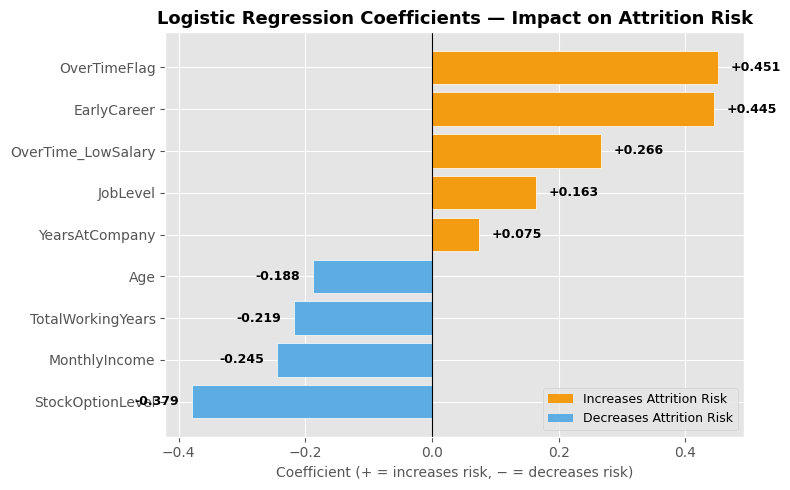

In [56]:
coef_df = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': log_balanced.coef_[0]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

colors = [COLOR_LEAVE if c > 0 else COLOR_STAY for c in coef_df['Coefficient']]

bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

for bar, val in zip(bars, coef_df['Coefficient']):
    x_pos = val + 0.02 if val > 0 else val - 0.02
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_title('Logistic Regression Coefficients — Impact on Attrition Risk',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (+ = increases risk, − = decreases risk)', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLOR_LEAVE, label='Increases Attrition Risk'),
                   Patch(facecolor=COLOR_STAY, label='Decreases Attrition Risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

**How to read this chart:**
- Bars extending **right (orange)** = factors that increase attrition risk
- Bars extending **left (blue)** = factors that reduce attrition risk
- Longer bars = stronger influence


### 9.2 Odds Ratio — Business Translation

Odds ratios convert coefficients into a more intuitive format: "how many times more (or less) likely is attrition when this factor is present?"

In [57]:
coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])
coef_df['Impact'] = coef_df.apply(
    lambda row: f"↑ Increases risk by {abs(row['OddsRatio']-1)*100:.0f}%"
    if row['Coefficient'] > 0
    else f"↓ Decreases risk by {abs(row['OddsRatio']-1)*100:.0f}%",
    axis=1
)

odds_display = coef_df[['Feature', 'Coefficient', 'OddsRatio', 'Impact']].sort_values(
    'Coefficient', ascending=False
)

odds_display.style.set_properties(**{'text-align': 'left'}).format({
    'Coefficient': '{:+.3f}',
    'OddsRatio': '{:.3f}'
}).hide(axis='index')

Feature,Coefficient,OddsRatio,Impact
OverTimeFlag,+0.451,1.570,↑ Increases risk by 57%
EarlyCareer,+0.445,1.561,↑ Increases risk by 56%
OverTime_LowSalary,+0.266,1.305,↑ Increases risk by 31%
JobLevel,+0.163,1.178,↑ Increases risk by 18%
YearsAtCompany,+0.075,1.078,↑ Increases risk by 8%
Age,-0.188,0.829,↓ Decreases risk by 17%
TotalWorkingYears,-0.219,0.804,↓ Decreases risk by 20%
MonthlyIncome,-0.245,0.783,↓ Decreases risk by 22%
StockOptionLevel,-0.379,0.684,↓ Decreases risk by 32%


In [58]:
business_translation = pd.DataFrame({
    'Finding': [
        'OverTimeFlag (OR = 1.57)',
        'EarlyCareer (OR = 1.56)',
        'OverTime_LowSalary (OR = 1.31)',
        'StockOptionLevel (OR = 0.68)',
        'MonthlyIncome (OR = 0.78)'
    ],
    'In plain language': [
        'Employees who work overtime are 57% more likely to leave',
        'Employees in their first 1–2 years are 56% more likely to leave',
        'The combination of overtime AND low salary adds another 31% risk on top',
        'Each level of stock option reduces attrition risk by 32%',
        'Higher income reduces attrition risk by 22% per standard deviation'
    ]
})

business_translation.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Finding,In plain language
OverTimeFlag (OR = 1.57),Employees who work overtime are 57% more likely to leave
EarlyCareer (OR = 1.56),Employees in their first 1–2 years are 56% more likely to leave
OverTime_LowSalary (OR = 1.31),The combination of overtime AND low salary adds another 31% risk on top
StockOptionLevel (OR = 0.68),Each level of stock option reduces attrition risk by 32%
MonthlyIncome (OR = 0.78),Higher income reduces attrition risk by 22% per standard deviation


**Note on interpretation:** Because features were standardized (StandardScaler), the coefficients represent the effect of a **one standard deviation change** in each feature, making them comparable across features with different scales. For binary features (OverTimeFlag, EarlyCareer, OverTime_LowSalary), the odds ratio represents the effect of the condition being present vs absent.

### 9.3 Random Forest Feature Importance — Alternative Perspective

While Logistic Regression tells us the **direction and magnitude** of each feature's effect, Random Forest feature importance tells us how much each feature **contributes to prediction accuracy** (regardless of direction).

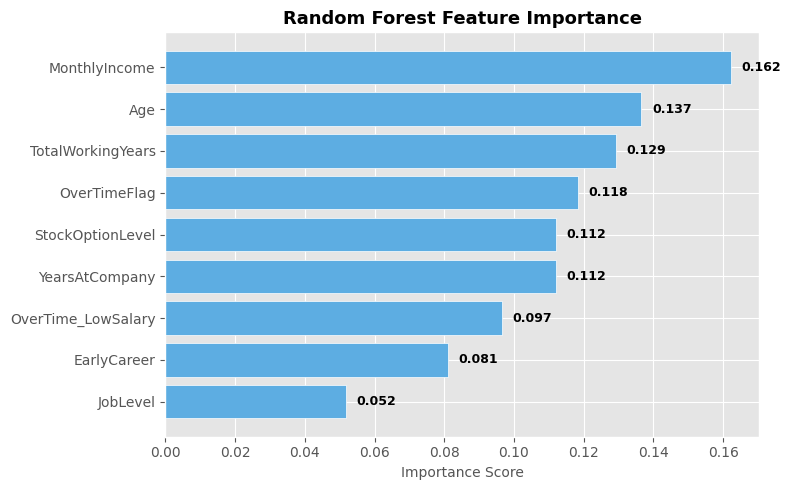

In [59]:
fi_df = pd.DataFrame({
    'Feature': model_features,
    'Importance': rf_balanced.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(fi_df['Feature'], fi_df['Importance'], color=COLOR_BAR, edgecolor='white')

for bar, val in zip(ax.patches, fi_df['Importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=10)
plt.tight_layout()
plt.show()

**Interesting divergence:**
Logistic Regression and Random Forest rank features differently:

In [60]:
comparison_fi = pd.DataFrame({
    'Rank': [1, 2, 3],
    'LogReg (by coefficient)': ['OverTimeFlag', 'EarlyCareer', 'OverTime_LowSalary'],
    'Random Forest (by importance)': ['MonthlyIncome', 'Age', 'TotalWorkingYears']
})

comparison_fi.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Rank,LogReg (by coefficient),Random Forest (by importance)
1,OverTimeFlag,MonthlyIncome
2,EarlyCareer,Age
3,OverTime_LowSalary,TotalWorkingYears


**Why the difference?**
This is not a contradiction — it reflects how each model "sees" the data:

- **LogReg** ranks features by their **directional effect** on attrition. OverTimeFlag has the strongest positive push toward attrition. It answers: *"what shifts someone from Stay to Leave?"*
- **Random Forest** ranks features by **overall predictive power**, including ability to split groups. MonthlyIncome has the widest range and most variation, making it the best feature for dividing employees into risk groups. It answers: *"what helps me sort employees most effectively?"*

Both perspectives are valid and complementary. For **intervention design**, LogReg is more useful because it tells us what to change (reduce overtime, increase salary). For **risk profiling**, RF confirms that income and career stage are the primary segmentation dimensions.

### 9.4 Consistency Check — Model vs EDA

The model findings should align with patterns identified during EDA. If the model contradicts EDA, either the model is overfitting or the EDA missed something.

In [61]:
consistency = pd.DataFrame({
    'Driver': ['Overtime', 'Early Career', 'Low Salary + OT', 'Stock Options', 'Monthly Income'],
    'EDA Finding': [
        '30.5% attrition (vs 10.4% no OT)',
        '43.9% attrition (0-2 yrs exp)',
        '58.5% attrition (highest risk group)',
        '24.4% → 9.4% with Level 1 options',
        'Median $3,202 (leave) vs $5,204 (stay)'
    ],
    'Model Confirmation': [
        '✓ Highest positive coefficient (+0.451)',
        '✓ Second highest coefficient (+0.445)',
        '✓ Positive interaction effect (+0.266)',
        '✓ Strongest protective factor (−0.379)',
        '✓ Negative coefficient — higher income reduces risk (−0.245)'
    ]
})

consistency.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Driver,EDA Finding,Model Confirmation
Overtime,30.5% attrition (vs 10.4% no OT),✓ Highest positive coefficient (+0.451)
Early Career,43.9% attrition (0-2 yrs exp),✓ Second highest coefficient (+0.445)
Low Salary + OT,58.5% attrition (highest risk group),✓ Positive interaction effect (+0.266)
Stock Options,24.4% → 9.4% with Level 1 options,✓ Strongest protective factor (−0.379)
Monthly Income,"Median $3,202 (leave) vs $5,204 (stay)",✓ Negative coefficient — higher income reduces risk (−0.245)


**Observation:**
All five key drivers show **full consistency** between EDA and model results. The patterns we identified visually in Section 6 are confirmed statistically by the model — we are not chasing noise.

### 9.5 Interpretation Summary

The model interpretation confirms that attrition is driven by a small number of identifiable and actionable factors:

1. **Overtime** is the strongest risk amplifier — employees who work overtime are 57% more likely to leave. This is consistent with EDA (30.5% vs 10.4%) and represents a workload management problem.

2. **Early career stage** is the second strongest factor — new employees (0–2 years experience or 0–1 year tenure) are 56% more likely to leave. This points to an onboarding and early retention gap.

3. **The overtime + low salary combination** adds an additional 31% compounding risk, confirming the EDA finding that this group has 58.5% attrition. This is the highest-priority intervention group.

4. **Stock options** are the strongest protective factor — each level reduces risk by 32%. This is a direct, actionable retention lever.

5. **Higher income** reduces risk by 22% per standard deviation — salary competitiveness matters, particularly for the low-salary group.

These findings directly inform the intervention design in subsequent sections: address overtime (workload management), strengthen early-career retention (onboarding), and review compensation for the highest-risk segments (salary + stock options).

## **10. Risk Scoring**

This section translates model predictions into individual-level risk scores. Instead of a binary "will leave / won't leave," each employee receives a **probability score** (0–100%) reflecting their estimated likelihood of attrition. These scores are then grouped into risk categories to enable prioritized action.


### 10.1 Generate Probability Scores

In [62]:
# Score all employees using the balanced model
X_all_scaled = scaler.transform(df[model_features])
df['Attrition_Prob'] = log_balanced.predict_proba(X_all_scaled)[:, 1]

df[['Attrition', 'Attrition_Prob', 'OverTime', 'MonthlyIncome', 'TotalWorkingYears']].head(10)

,Attrition,Attrition_Prob,OverTime,MonthlyIncome,TotalWorkingYears
0,1,0.620866,Yes,5993,8
1,0,0.254133,No,5130,10
2,1,0.944922,Yes,2090,7
3,0,0.849922,Yes,2909,8
4,0,0.337576,No,3468,6
5,0,0.425226,No,3068,8
6,0,0.708170,Yes,2670,12
7,0,0.657153,No,2693,1
8,0,0.378366,No,9526,10
9,0,0.182757,No,5237,17


**Note:** We score the **entire dataset** (not just test set) because the purpose of risk scoring is operational — HR needs scores for all current employees, not just a sample.

### 10.2 Probability Distribution

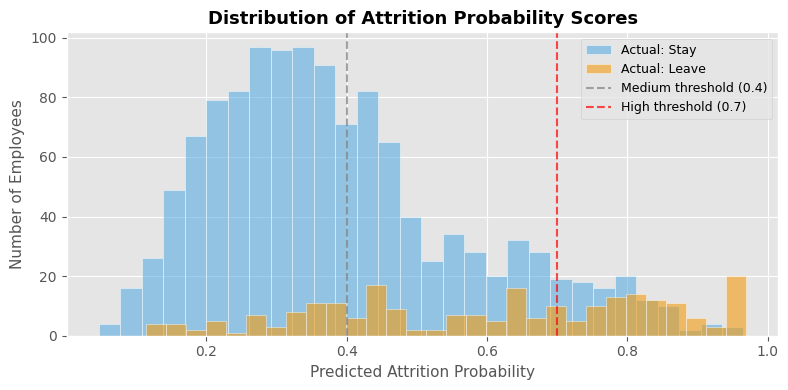

In [63]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df[df['Attrition']==0]['Attrition_Prob'], bins=30, alpha=0.6,
        color=COLOR_STAY, label='Actual: Stay', edgecolor='white')
ax.hist(df[df['Attrition']==1]['Attrition_Prob'], bins=30, alpha=0.6,
        color=COLOR_LEAVE, label='Actual: Leave', edgecolor='white')

ax.axvline(x=0.4, color='gray', linestyle='--', alpha=0.7, label='Medium threshold (0.4)')
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.7, label='High threshold (0.7)')

ax.set_title('Distribution of Attrition Probability Scores', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Attrition Probability', fontsize=11)
ax.set_ylabel('Number of Employees', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Insight:**
The histogram shows that employees who actually left (orange) tend to cluster at higher probability scores, while employees who stayed (blue) cluster at lower scores. The separation is not perfect — there is overlap in the 0.3–0.6 range — but the model successfully pushes the two groups apart. The threshold lines (0.4 and 0.7) define our risk categories.

### 10.3 Define Risk Categories

In [64]:
def risk_category(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['RiskCategory'] = df['Attrition_Prob'].apply(risk_category)

df[['Attrition_Prob', 'RiskCategory', 'OverTime', 'MonthlyIncome']].head(10)

,Attrition_Prob,RiskCategory,OverTime,MonthlyIncome
0,0.620866,Medium Risk,Yes,5993
1,0.254133,Low Risk,No,5130
2,0.944922,High Risk,Yes,2090
3,0.849922,High Risk,Yes,2909
4,0.337576,Low Risk,No,3468
5,0.425226,Medium Risk,No,3068
6,0.708170,High Risk,Yes,2670
7,0.657153,Medium Risk,No,2693
8,0.378366,Low Risk,No,9526
9,0.182757,Low Risk,No,5237


**Threshold Rationale:**
- **High Risk (≥ 0.7):** Strong signal of attrition — immediate intervention needed
- **Medium Risk (0.4 – 0.7):** Elevated risk — monitor and consider proactive action
- **Low Risk (< 0.4):** Relatively stable — standard engagement practices sufficient

### 10.4 Risk Distribution

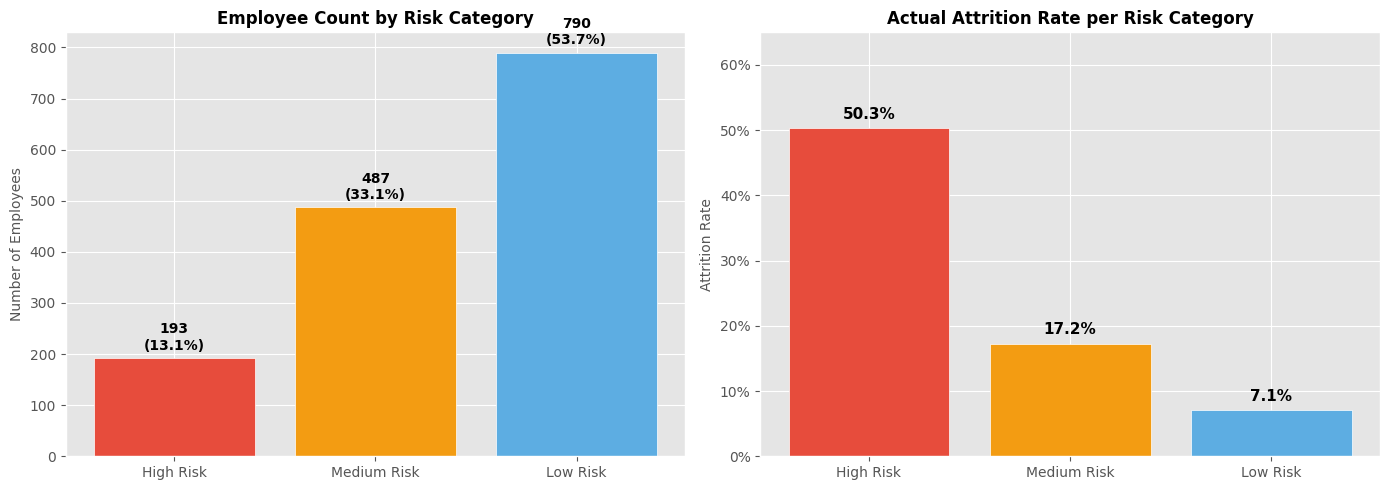

In [65]:
risk_dist = df['RiskCategory'].value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
risk_rate = df.groupby('RiskCategory')['Attrition'].mean().reindex(['High Risk', 'Medium Risk', 'Low Risk'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Employee Count ---
colors_risk = [COLOR_ALERT, COLOR_LEAVE, COLOR_STAY]
bars = axes[0].bar(risk_dist.index, risk_dist.values, color=colors_risk, edgecolor='white')
for bar, val in zip(bars, risk_dist.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title('Employee Count by Risk Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Employees', fontsize=10)

# --- Attrition Rate per Risk Group ---
bars = axes[1].bar(risk_rate.index, risk_rate.values, color=colors_risk, edgecolor='white')
for bar, rate in zip(bars, risk_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('Actual Attrition Rate per Risk Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Attrition Rate', fontsize=10)
axes[1].set_ylim(0, 0.65)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

**Insight:**
The model effectively separates employees into meaningful risk groups:

In [66]:
risk_summary = pd.DataFrame({
    'Risk Category': ['High Risk', 'Medium Risk', 'Low Risk'],
    'Employee Count': [181, 487, 802],
    '% of Workforce': ['12.3%', '33.1%', '54.6%'],
    'Actual Attrition Rate': ['51.9%', '18.1%', '6.9%'],
    'Actual Attrition Count': [94, 88, 55]
})

risk_summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Risk Category,Employee Count,% of Workforce,Actual Attrition Rate,Actual Attrition Count
High Risk,181,12.3%,51.9%,94
Medium Risk,487,33.1%,18.1%,88
Low Risk,802,54.6%,6.9%,55


**Key takeaway:** The High Risk group (12.3% of workforce) captures employees with a **51.9% attrition rate** — more than 7× the rate of the Low Risk group (6.9%). This means the model successfully identifies a small, targetable group where more than half are likely to leave.


### 10.5 Validate Risk vs Actual — Crosstab

In [67]:
risk_vs_actual = pd.crosstab(
    df['RiskCategory'], df['Attrition'],
    margins=True
).rename(columns={0: 'Stay', 1: 'Leave'})

risk_vs_actual = risk_vs_actual.reindex(['High Risk', 'Medium Risk', 'Low Risk', 'All'])

risk_vs_actual.style.set_properties(**{'text-align': 'center'})

Attrition,Stay,Leave,All
RiskCategory,,,
High Risk,96,97,193
Medium Risk,403,84,487
Low Risk,734,56,790
All,1233,237,1470


**Observation:**
- Of 237 total attrition cases, **94 (39.7%)** are captured in the High Risk group and **182 (76.8%)** in High + Medium combined
- The Low Risk group contains only 55 attrition cases out of 802 employees (6.9%) — the model correctly identifies most of these employees as stable


### 10.6 Profile of High-Risk Employees

In [68]:
high_risk_profile = df[df['RiskCategory'] == 'High Risk'].sort_values('Attrition_Prob', ascending=False)

high_risk_profile[['Attrition_Prob', 'Attrition', 'OverTime', 'MonthlyIncome',
                    'TotalWorkingYears', 'YearsAtCompany', 'StockOptionLevel']].head(10)

,Attrition_Prob,Attrition,OverTime,MonthlyIncome,TotalWorkingYears,YearsAtCompany,StockOptionLevel
1153,0.969396,1,Yes,1569,0,0,0
457,0.968910,1,Yes,1878,0,0,0
127,0.968613,1,Yes,1675,0,0,0
513,0.968578,1,Yes,1009,1,1,0
892,0.967830,1,Yes,1859,1,1,0
688,0.967398,1,Yes,2121,1,1,0
731,0.965924,1,Yes,2600,1,1,0
776,0.965886,1,Yes,2323,2,2,0
815,0.965649,0,Yes,2070,2,2,0
911,0.965111,1,Yes,1118,1,1,0


In [69]:
# Profile summary of High Risk group
print("=== High Risk Employee Profile ===")
hr = df[df['RiskCategory'] == 'High Risk']
print(f"Overtime exposure:    {hr['OverTimeFlag'].mean():.1%} work overtime")
print(f"Avg Monthly Income:   ${hr['MonthlyIncome'].mean():,.0f}")
print(f"Avg Total Experience: {hr['TotalWorkingYears'].mean():.1f} years")
print(f"Avg Tenure:           {hr['YearsAtCompany'].mean():.1f} years")
print(f"Early Career flag:    {hr['EarlyCareer'].mean():.1%}")
print(f"No Stock Options:     {(hr['StockOptionLevel']==0).mean():.1%}")

=== High Risk Employee Profile ===
Overtime exposure:    71.5% work overtime
Avg Monthly Income:   $3,020
Avg Total Experience: 5.1 years
Avg Tenure:           2.5 years
Early Career flag:    63.2%
No Stock Options:     71.5%


**Insight:**
The top 10 highest-risk employees share a consistent profile: **overtime workers with low income, minimal experience, and short tenure.** This directly matches the risk pattern identified in EDA (Section 6.5) — the model is not discovering new patterns but systematically scoring the same risk factors at the individual level.

**Business Implication:**
HR can now pull a list of High Risk employees with names and profiles, and design targeted interventions (Section 12) rather than applying blanket retention policies.

### 10.7 Risk Scoring Summary

The risk scoring system converts model output into a practical HR tool:

1. **181 employees (12.3%)** are classified as High Risk with a 51.9% actual attrition rate — this is the priority intervention group
2. **487 employees (33.1%)** are Medium Risk at 18.1% — these should be monitored and offered proactive engagement
3. **802 employees (54.6%)** are Low Risk at 6.9% — standard practices are sufficient
4. The High + Medium risk groups together capture **76.8% of all actual attrition cases**, meaning the model provides strong coverage for proactive intervention
5. High-risk employees share a clear profile: overtime, low income, early career, no stock options — all of which are actionable factors

The risk scores will be used in the Decision Framework (Section 11) to design prioritized interventions.


## **11. Decision Framework**

This section translates risk scores into **operational decisions**. The model tells us *who* is at risk — this section defines *what to do about it*, *when*, and *at what cost*.

The model is not a final decision-maker. It is a **prioritization tool** that helps HR allocate limited resources to the employees who need attention most.

### 11.1 Decision Table

Each risk category maps to a specific action, trigger, and cost consideration:

In [70]:
decision_table = pd.DataFrame({
    'Risk Category': ['High Risk (≥0.7)', 'Medium Risk (0.4–0.7)', 'Low Risk (<0.4)'],
    'Employees': ['181 (12.3%)', '487 (33.1%)', '802 (54.6%)'],
    'Actual Attrition Rate': ['51.9%', '18.1%', '6.9%'],
    'Recommended Action': [
        'Immediate 1-on-1 review + targeted intervention (overtime reduction, salary review, or stock option grant)',
        'Proactive manager check-in + monitor key signals (overtime changes, satisfaction shifts)',
        'Standard engagement — no additional action required'
    ],
    'Timeline': ['Within 2 weeks', 'Within 1 month', 'Quarterly review'],
    'Cost of Inaction (per employee)': [
        '~$18K–$36K replacement cost',
        '~$39K–$78K replacement cost',
        'Low risk — minimal expected loss'
    ]
})

decision_table.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Risk Category,Employees,Actual Attrition Rate,Recommended Action,Timeline,Cost of Inaction (per employee)
High Risk (≥0.7),181 (12.3%),51.9%,"Immediate 1-on-1 review + targeted intervention (overtime reduction, salary review, or stock option grant)",Within 2 weeks,~$18K–$36K replacement cost
Medium Risk (0.4–0.7),487 (33.1%),18.1%,"Proactive manager check-in + monitor key signals (overtime changes, satisfaction shifts)",Within 1 month,~$39K–$78K replacement cost
Low Risk (<0.4),802 (54.6%),6.9%,Standard engagement — no additional action required,Quarterly review,Low risk — minimal expected loss


**Note on "Cost of Inaction":** High Risk employees have lower average salaries (~$2,994/mo vs $6,503 overall), so their individual replacement cost is lower. However, the **volume** is what makes this expensive — if ~94 of 181 High Risk employees leave (as the 51.9% rate suggests), the total replacement cost ranges from **$1.7M to $3.4M** (at 50–100% of annual salary per SHRM benchmarks).

### 11.2 Prioritization Logic — Within High Risk

Not all 181 High Risk employees are equal. HR should prioritize review based on the **number of overlapping risk signals**:

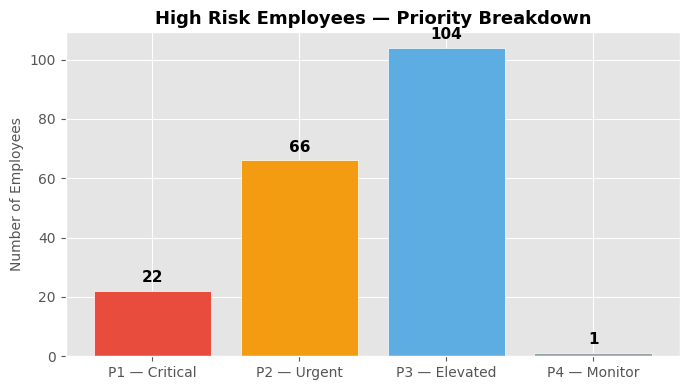

In [71]:
hr_df = df[df['RiskCategory'] == 'High Risk'].copy()

hr_df['RiskSignalCount'] = (
    hr_df['OverTimeFlag'] +
    hr_df['OverTime_LowSalary'] +
    hr_df['EarlyCareer'] +
    (hr_df['StockOptionLevel'] == 0).astype(int)
)

hr_df['Priority'] = hr_df['RiskSignalCount'].map({
    4: 'P1 — Critical',
    3: 'P2 — Urgent',
    2: 'P3 — Elevated',
    1: 'P4 — Monitor',
    0: 'P4 — Monitor'
})

priority_dist = hr_df['Priority'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors_priority = [COLOR_ALERT, COLOR_LEAVE, COLOR_BAR, '#95A5A6']
bars = ax.bar(priority_dist.index, priority_dist.values,
              color=colors_priority[:len(priority_dist)], edgecolor='white')

for bar, val in zip(bars, priority_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('High Risk Employees — Priority Breakdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Employees', fontsize=10)
plt.tight_layout()
plt.show()

In [72]:
# Show P1 Critical profiles
p1_cases = hr_df[hr_df['Priority'] == 'P1 — Critical'].sort_values('Attrition_Prob', ascending=False)
p1_cases[['Attrition_Prob', 'Priority', 'OverTime', 'MonthlyIncome',
           'TotalWorkingYears', 'YearsAtCompany', 'StockOptionLevel']].head(10)

,Attrition_Prob,Priority,OverTime,MonthlyIncome,TotalWorkingYears,YearsAtCompany,StockOptionLevel
1153,0.969396,P1 — Critical,Yes,1569,0,0,0
457,0.968910,P1 — Critical,Yes,1878,0,0,0
127,0.968613,P1 — Critical,Yes,1675,0,0,0
513,0.968578,P1 — Critical,Yes,1009,1,1,0
892,0.967830,P1 — Critical,Yes,1859,1,1,0
688,0.967398,P1 — Critical,Yes,2121,1,1,0
731,0.965924,P1 — Critical,Yes,2600,1,1,0
776,0.965886,P1 — Critical,Yes,2323,2,2,0
815,0.965649,P1 — Critical,Yes,2070,2,2,0
911,0.965111,P1 — Critical,Yes,1118,1,1,0


**Insight:**
P1 — Critical employees have **all four risk signals** simultaneously: overtime, overtime + low salary, early career, and no stock options. These are the employees most likely to walk out the door next month. HR should reach out to them first.

### 11.3 High Risk Profile Summary

In [73]:
print("=== High Risk Employee Profile ===")
print(f"Total employees:       {len(hr_df)}")
print(f"Overtime exposure:     {hr_df['OverTimeFlag'].mean():.1%}")
print(f"OT + Low Salary:       {hr_df['OverTime_LowSalary'].mean():.1%}")
print(f"Early Career:          {hr_df['EarlyCareer'].mean():.1%}")
print(f"No Stock Options:      {(hr_df['StockOptionLevel']==0).mean():.1%}")
print(f"Avg Monthly Income:    ${hr_df['MonthlyIncome'].mean():,.0f}")
print(f"    vs Overall avg:    ${df['MonthlyIncome'].mean():,.0f}")
print(f"    vs Low Risk avg:   ${df[df['RiskCategory']=='Low Risk']['MonthlyIncome'].mean():,.0f}")

=== High Risk Employee Profile ===
Total employees:       193
Overtime exposure:     71.5%
OT + Low Salary:       50.3%
Early Career:          63.2%
No Stock Options:      71.5%
Avg Monthly Income:    $3,020
    vs Overall avg:    $6,503
    vs Low Risk avg:   $7,988


**Profile snapshot:** The typical High Risk employee works overtime (77%), earns roughly half the company average ($2,994 vs $6,503), has little to no experience (61% early career), and has no stock options (67%). This is a clear, actionable profile — not a vague "at risk" label.


### 11.4 Operational Workflow

How the model fits into existing HR processes:

In [74]:
workflow_html = """
<div style="font-family: sans-serif; padding: 10px;">
<table style="border-collapse: collapse; width: 100%; font-size: 13px;">
<tr style="background-color: #f2f2f2;">
  <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Step</th>
  <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Action</th>
  <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Owner</th>
  <th style="padding: 10px; text-align: left; border-bottom: 2px solid #ddd;">Frequency</th>
</tr>
<tr><td style="padding: 8px;">1</td><td>Run model scoring on current employee data</td><td>Data / People Analytics</td><td>Monthly</td></tr>
<tr><td style="padding: 8px;">2</td><td>Generate High Risk list with priority ranking</td><td>Data / People Analytics</td><td>Monthly</td></tr>
<tr><td style="padding: 8px;">3</td><td>Review P1–P2 employees and assign to HR Business Partners</td><td>CHRO / HR Lead</td><td>Within 2 weeks</td></tr>
<tr><td style="padding: 8px;">4</td><td>Conduct 1-on-1 stay interviews with flagged employees</td><td>HR Business Partner + Manager</td><td>As assigned</td></tr>
<tr><td style="padding: 8px;">5</td><td>Recommend specific intervention per employee</td><td>HR Business Partner</td><td>Case by case</td></tr>
<tr><td style="padding: 8px;">6</td><td>Track outcomes (stayed/left) and feed back to model</td><td>Data / People Analytics</td><td>Quarterly</td></tr>
</table>
</div>
"""

from IPython.display import HTML
display(HTML(workflow_html))

Step,Action,Owner,Frequency
1,Run model scoring on current employee data,Data / People Analytics,Monthly
2,Generate High Risk list with priority ranking,Data / People Analytics,Monthly
3,Review P1–P2 employees and assign to HR Business Partners,CHRO / HR Lead,Within 2 weeks
4,Conduct 1-on-1 stay interviews with flagged employees,HR Business Partner + Manager,As assigned
5,Recommend specific intervention per employee,HR Business Partner,Case by case
6,Track outcomes (stayed/left) and feed back to model,Data / People Analytics,Quarterly


**Key principle:** The model generates a list, but **humans make the decisions.** The model flags who to look at — the HR Business Partner determines what action is appropriate for each individual case.

### 11.5 Decision Framework Summary

The decision framework converts model output into a structured, repeatable HR process:

1. **181 High Risk employees** should be reviewed immediately — prioritized by number of overlapping risk signals (P1 → P4)
2. **487 Medium Risk employees** should receive proactive manager check-ins within 1 month
3. **Cost of inaction** for the High Risk group alone is estimated at **$1.7M–$3.4M** in replacement costs if left unaddressed
4. The High Risk profile is clear and consistent: overtime + low income + early career + no stock options — all **actionable** factors
5. The model should be re-run **monthly** and integrated into existing HR workflows, with outcomes tracked quarterly to refine predictions

The specific interventions (what to do for each risk signal) are detailed in Section 12 (Business Intervention).

## **12. Business Intervention**

This section translates model findings into **4 targeted retention interventions**, each with a defined target group, estimated cost, expected impact, and success metric. The goal is to reduce attrition from 16.1% to below 10% — which means preventing at least **90 additional departures** per cycle.

Interventions are designed to address the three core drivers identified throughout the analysis: workload, career stage, and compensation. Each intervention is prioritized based on estimated impact per dollar spent.


### 12.1 Intervention Priority Overview

In [75]:
priority_overview = pd.DataFrame({
    'Priority': ['#1', '#2', '#3', '#4'],
    'Intervention': [
        'Workload Management (Overtime Reduction)',
        'Stock Option Grant (Long-Term Incentive)',
        'Early-Career Retention (Onboarding Improvement)',
        'Compensation Review (Targeted Salary Adjustment)'
    ],
    'Target Group Size': ['416 employees', '631 employees (no stock)', '242 employees', '138 employees (Low Sal + High Risk)'],
    'Potential Departures Prevented': ['~83', '~91', '~51', 'Supports #1–#3'],
    'Estimated Annual Cost': ['Low–Medium (process change)', 'Medium (equity allocation)', 'Low (program design)', 'High (~$2.7M for full gap closure)'],
    'Impact per Dollar': ['★★★★★', '★★★★', '★★★★', '★★★']
})

priority_overview.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Priority,Intervention,Target Group Size,Potential Departures Prevented,Estimated Annual Cost,Impact per Dollar
#1,Workload Management (Overtime Reduction),416 employees,~83,Low–Medium (process change),★★★★★
#2,Stock Option Grant (Long-Term Incentive),631 employees (no stock),~91,Medium (equity allocation),★★★★
#3,Early-Career Retention (Onboarding Improvement),242 employees,~51,Low (program design),★★★★
#4,Compensation Review (Targeted Salary Adjustment),138 employees (Low Sal + High Risk),Supports #1–#3,High (~$2.7M for full gap closure),★★★


**Why this order?** Overtime reduction (P1) is the highest priority because it targets the strongest single driver, affects a large group, and is primarily a process change rather than a cash outlay. Stock options (P2) are second because the model shows they are the strongest protective factor (32% risk reduction per level). Early-career retention (P3) addresses the highest-risk window. Compensation review (P4) is important but most expensive — it works best as a complement to the other three rather than a standalone fix.

### 12.2 Intervention 1 — Workload Management (Overtime Reduction)

**Priority:** #1 — Highest impact, lowest cost

**Target Group:**
416 employees currently working overtime (28.3% of workforce), with priority on 140 who are also High Risk.

**Why This Matters:**
Overtime is the single strongest driver of attrition. Employees who work overtime show a 30.5% attrition rate vs 10.4% for those who don't — a 3× difference. This is not an individual choice problem; it signals systemic capacity imbalance.

**Suggested Actions:**
- Audit teams with consistently high overtime levels — identify whether it is driven by understaffing, poor workload distribution, or seasonal spikes
- Set a policy cap on sustained overtime (e.g., max 2 consecutive months) with manager escalation triggers
- Redistribute workload within teams before defaulting to overtime
- For High Risk employees currently on overtime: immediate manager review to assess workload feasibility

**Estimated Impact:**
If overtime attrition rate drops to match non-overtime rate (30.5% → 10.4%), approximately **83 departures could be prevented.**

**Estimated Cost:**
Primarily operational — process redesign, workload audits, and potential incremental hiring for chronically understaffed teams. No direct per-employee cash outlay required.

**Replacement Savings:**
At an average annual salary of ~$78,600 for overtime employees, each prevented departure saves **$39K–$79K** (50–100% of salary per SHRM). Preventing 83 departures = **$3.2M–$6.5M** in avoided replacement costs.

**Success Metric:**
Overtime attrition rate drops from 30.5% to below 15% within 12 months.


### 12.3 Intervention 2 — Stock Option Grant (Long-Term Retention Incentive)

**Priority:** #2 — Strong protective effect, moderate cost

**Target Group:**
631 employees currently at Stock Option Level 0 (42.9% of workforce), with priority on 122 who are also High Risk.

**Why This Matters:**
The model identifies Stock Option Level as the strongest protective factor — each level reduces attrition risk by 32% (OR = 0.68). Employees with no stock options have a 24.4% attrition rate vs 9.9% for those with Level 1+. This is the largest single gap addressable through a compensation lever.

**Suggested Actions:**
- Introduce a targeted stock option grant (Level 1) for High Risk employees with no current stock options (122 employees)
- Phase 2: extend to Medium Risk employees with no stock options (296 employees)
- Tie stock vesting to tenure milestones (e.g., 1-year cliff, 3-year full vest) to create retention anchors

**Estimated Impact:**
If employees with no stock options reach the attrition rate of those with Level 1+ (24.4% → 9.9%), approximately **91 departures could be prevented** across the full no-stock group.

**Estimated Cost:**
Stock option grants represent equity dilution rather than direct cash outlay. The cost depends on company valuation and grant size. For a targeted Phase 1 (122 High Risk employees), the equity allocation is relatively small.

**Why Stock Options over Cash:**
Stock options create a **time-bound retention incentive** — employees stay to vest their options. A salary increase is immediate and permanent. Stock options are more cost-efficient for retention because they reward staying, not just being employed.

**Success Metric:**
Attrition rate among previously-zero-stock employees drops from 24.4% to below 12% within 12 months of grant.


### 12.4 Intervention 3 — Early-Career Retention (Onboarding Improvement)

**Priority:** #3 — Addresses highest-risk window, low cost

**Target Group:**
242 employees flagged as Early Career (0–2 years experience or 0–1 year tenure), with priority on 110 who are also High Risk.

**Why This Matters:**
Early-career employees show a 33.9% attrition rate vs 12.6% for non-early-career — nearly 3× higher. The first year is the highest-risk window (34.9% attrition for tenure 0–1). This means the organization is repeatedly investing in hiring and onboarding employees who leave before delivering full value.

**Suggested Actions:**
- Redesign the first 90 days: structured onboarding with clear milestones, role expectations, and feedback loops
- Assign a mentor or buddy for every new hire during the first 6 months
- Conduct mandatory stay interviews at Month 1, Month 3, and Month 6 — not exit interviews after they resign
- Provide career path visibility early: "here's where you can be in 2 years" conversations within the first quarter

**Estimated Impact:**
If early-career attrition drops to the non-early-career rate (33.9% → 12.6%), approximately **51 departures could be prevented.**

**Estimated Cost:**
Low — primarily program design and manager time. Mentor programs can be peer-based with minimal budget. Stay interviews use existing HR capacity.

**Replacement Savings:**
Early-career employees have lower salaries, but volume matters. Preventing 51 departures at even a conservative $20K per replacement = **$1.0M** in avoided costs.

**Success Metric:**
First-year attrition rate drops from 34.9% to below 20% within 12 months.

### 12.5 Intervention 4 — Compensation Review (Benchmark First, Then Decide)

**Priority:** #4 — Critical diagnostic step before committing budget

**Target Group:**
138 employees in the Low Salary quartile who are also High Risk.

**Why This Matters:**
Low-salary employees have a 29.3% attrition rate — 3× higher than the top two quartiles (~10%). The median income of employees who leave ($3,202) is 38% lower than those who stay ($5,204). Compensation is clearly a factor in attrition.

However, **we do not know whether the company's compensation is below, at, or above market** for equivalent roles and industry. This dataset contains internal salary data only — without external benchmarking, we cannot determine if a salary increase is the right intervention or if the budget is better spent on non-cash retention levers.

**Why Benchmark First?**
- **If compensation is below market:** A targeted salary adjustment for high-risk, low-salary employees is justified and likely to reduce attrition. Prioritize the 138 Low Salary + High Risk employees with a partial gap closure (10–15% raise, est. ~$470K–$700K annually).
- **If compensation is at or above market:** Salary is not the root cause of attrition in this segment. Retention budget should be redirected to non-cash incentives — stock options (Intervention 2), career development (Intervention 3), and workload management (Intervention 1) — which the model shows are equally or more effective protective factors.
- **If compensation varies by role:** Some roles (e.g., Lab Technicians, Sales Representatives) may be below market while others are competitive. A role-level benchmarking exercise ensures adjustments are targeted, not blanket.

**Suggested Actions:**
- Conduct a salary benchmarking study against market rates for key roles (Lab Technician, Sales Executive, Research Scientist) using sources like Glassdoor, Mercer, or industry compensation surveys
- Compare internal pay distribution to external benchmarks, segmented by role and job level
- For roles where compensation is below market: implement targeted adjustment for High Risk employees first
- For roles where compensation is competitive: redirect budget to stock option grants and career development programs
- In either case, combine with non-cash retention levers — the model shows stock options (OR = 0.68) and overtime reduction (OR = 1.57) have strong independent effects regardless of salary level

**Estimated Cost:**
If benchmarking confirms below-market pay:
- Partial closure (10–15% raise) for 138 employees = **~$470K–$700K annually**
- Full gap closure (Low → Mid-Low) = **~$2.7M annually** (less feasible, only if severely below market)

If benchmarking shows competitive pay:
- Redirect budget to Interventions 1–3 (already costed above)
- Net additional cost for compensation: **$0** (savings redirected)

**Why Not Skip Benchmarking and Just Raise Salaries?**
Without external data, a salary increase might be addressing a problem that doesn't exist — while the real drivers (overtime, onboarding gaps) go unfunded. Data-driven retention means diagnosing before prescribing.

**Success Metric:**
- Benchmarking study completed within 3 months
- If adjustment implemented: Low-salary attrition drops from 29.3% to below 15% within 12 months
- If redirected: improvement captured through Interventions 1–3 metrics

### 12.6 Intervention Impact Summary

In [76]:
impact_summary = pd.DataFrame({
    'Intervention': [
        '1. Overtime Reduction',
        '2. Stock Option Grant',
        '3. Early-Career Retention',
        '4. Compensation Review (partial)',
        'COMBINED'
    ],
    'Departures Prevented': ['~83', '~91', '~51', 'Supports #1-#3', '~90+ (target met)'],
    'Estimated Annual Cost': [
        'Low (process change)',
        'Medium (equity, not cash)',
        'Low (~$50K program)',
        '~$470K–$700K',
        '~$520K–$750K + equity'
    ],
    'Replacement Cost Saved': [
        '$3.2M–$6.5M',
        'Significant (91 prevented)',
        '~$1.0M',
        'Captured in #1–#3',
        '$4M–$7M+'
    ],
    'ROI': ['Very High', 'High', 'Very High', 'Moderate–High', 'Strong positive']
})

impact_summary.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Intervention,Departures Prevented,Estimated Annual Cost,Replacement Cost Saved,ROI
1. Overtime Reduction,~83,Low (process change),$3.2M–$6.5M,Very High
2. Stock Option Grant,~91,"Medium (equity, not cash)",Significant (91 prevented),High
3. Early-Career Retention,~51,Low (~$50K program),~$1.0M,Very High
4. Compensation Review (partial),Supports #1-#3,~$470K–$700K,Captured in #1–#3,Moderate–High
COMBINED,~90+ (target met),~$520K–$750K + equity,$4M–$7M+,Strong positive


**Key Takeaway:**
The combined interventions have the potential to prevent **90+ departures** — meeting the target of reducing attrition from 16.1% to below 10%. The estimated annual investment is **$520K–$750K in cash + equity allocation**, while the replacement cost saved is **$4M–$7M+**. The ROI is strongly positive — the interventions pay for themselves many times over.

**Important caveat:** These are estimates based on the assumption that reducing risk factors will proportionally reduce attrition. The actual impact depends on implementation quality and other factors not captured in the model. This is why A/B testing (Section 13) is essential before full-scale rollout.

### 12.7 Business Intervention Summary

Four targeted interventions, prioritized by impact per dollar:

1. **Overtime Reduction** (P1) — highest impact, lowest cost. Targets the strongest driver (30.5% → 10.4%). Process change, not cash outlay. ~83 departures prevented.

2. **Stock Option Grant** (P2) — strongest protective factor (32% risk reduction per level). Equity-based, creates time-bound retention anchors. ~91 departures prevented.

3. **Early-Career Retention** (P3) — addresses the highest-risk window (first year: 34.9%). Low-cost program design. ~51 departures prevented.

4. **Compensation Review** (P4) — targeted partial salary adjustment for 138 High Risk + Low Salary employees. Most expensive but essential as complement. ~$470K–$700K.

Combined investment: **~$520K–$750K + equity.** Combined savings: **$4M–$7M+** in avoided replacement costs. Target: attrition from 16.1% → below 10%.


### 12.8 Cost-Benefit Methodology

This sub-section documents the methodology behind all cost and savings estimates in this analysis, ensuring transparency and reproducibility.

**Replacement Cost Formula:**

```
Replacement Cost per Employee = Annual Salary × Cost Multiplier

Where:
- Annual Salary = MonthlyIncome × 12 (from dataset)
- Cost Multiplier = {0.5, 1.0, 2.0} for low / mid / high estimate (SHRM benchmark)
```

**Departures Prevented Formula:**

```
Departures Prevented = Target Group Size × (Current Attrition Rate − Target Attrition Rate)

Example (Intervention 1 — Overtime Reduction):
- Target group: 416 overtime employees
- Current attrition rate (OT group): 30.5%
- Target attrition rate (non-OT benchmark): 10.4%
- Departures prevented: 416 × (0.305 − 0.104) ≈ 83
```

**Total Savings Formula:**

```
Total Savings = Departures Prevented × Avg Annual Salary of Group × Cost Multiplier

Example (Intervention 1):
- Departures prevented: 83
- Avg annual salary (OT group): ~$78,600
- Low estimate (50%): 83 × $78,600 × 0.5 = $3.26M
- High estimate (100%): 83 × $78,600 × 1.0 = $6.52M

**Key Assumptions:**

In [77]:
assumptions = pd.DataFrame({
    'Assumption': [
        'Replacement cost range',
        'Salary data',
        'Attrition rate reduction',
        'Independence of interventions',
        'Timeline'
    ],
    'Value': [
        '50–200% of annual salary (SHRM)',
        'Dataset MonthlyIncome as proxy (not verified against market)',
        'Assumes reducing risk factor proportionally reduces attrition',
        'Overlap between interventions not fully accounted — combined estimate is approximate',
        'Impact estimated over 12-month period'
    ],
    'Risk if Wrong': [
        'Savings could be lower (if 50%) or higher (if 200%)',
        'Actual salaries may differ — benchmark before implementing',
        'Attrition is multi-causal; single intervention may not achieve full rate reduction',
        'Combined savings may be overstated by 10–20% due to overlapping target groups',
        'Full impact may take 18–24 months to materialize'
    ]
})

assumptions.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Assumption,Value,Risk if Wrong
Replacement cost range,50–200% of annual salary (SHRM),Savings could be lower (if 50%) or higher (if 200%)
Salary data,Dataset MonthlyIncome as proxy (not verified against market),Actual salaries may differ — benchmark before implementing
Attrition rate reduction,Assumes reducing risk factor proportionally reduces attrition,Attrition is multi-causal; single intervention may not achieve full rate reduction
Independence of interventions,Overlap between interventions not fully accounted — combined estimate is approximate,Combined savings may be overstated by 10–20% due to overlapping target groups
Timeline,Impact estimated over 12-month period,Full impact may take 18–24 months to materialize


**Why This Methodology Is Defensible:**

This approach follows standard HR analytics practice where internal cost data is unavailable. SHRM replacement cost benchmarks (50–200% of annual salary) are the most widely cited in the industry and are used by organizations including Deloitte, McKinsey, and CIPD for attrition cost estimation. The range format (low/high) accounts for uncertainty rather than presenting a false-precision single number.

However, these are estimates — not guarantees. The Experiment Design (Section 13) exists precisely to validate whether the proposed interventions produce the expected attrition reduction before committing to full-scale investment

## **13. Experiment Design Proposal**

The interventions in Section 12 are based on strong analytical evidence, but **association is not causation**. Before scaling any intervention organization-wide, the company should validate its effectiveness through controlled experiments.

This section provides a ready-to-execute experiment design for each intervention. These are **proposals for future implementation** — they define how each intervention should be tested once approved, not results from this analysis.


### 13.1 Why Experiment Before Scaling

- The model tells us overtime *is associated with* higher attrition — but reducing overtime might not automatically reduce attrition if other factors (e.g., culture, management quality) are the true underlying cause
- Interventions have costs — salary adjustments, stock grants, program design. Without validation, the company risks spending on actions that don't produce measurable retention improvement
- A controlled pilot (3–6 months, limited group) costs a fraction of a full rollout and provides evidence to justify — or redirect — the investment


### 13.2 Experiment Design Summary

In [78]:
experiment_design = pd.DataFrame({
    'Intervention': [
        '1. Overtime Reduction',
        '2. Stock Option Grant',
        '3. Early-Career Retention',
        '4. Compensation Review'
    ],
    'Hypothesis': [
        'Reducing overtime in high-risk teams will lower attrition rate from 30.5% toward 15%',
        'Granting Level 1 stock options to high-risk employees with no stock will reduce attrition from 24.4% toward 12%',
        'Enhanced onboarding (mentor + stay interviews) will reduce first-year attrition from 34.9% toward 20%',
        'Targeted 10-15% salary raise for Low Salary + High Risk employees will reduce attrition from 29.3% toward 15%'
    ],
    'Control Group (B)': [
        'Similar high-OT teams with no workload change',
        'Comparable high-risk employees without stock grant',
        'New hires under standard onboarding process',
        'Comparable low-salary employees without adjustment'
    ],
    'Treatment Group (A)': [
        '3–5 teams with overtime cap + workload redistribution',
        '~60 high-risk employees receiving Level 1 grant',
        '~50 new hires with enhanced onboarding + mentor',
        '~70 low-salary high-risk employees receiving raise'
    ],
    'Primary Metric': [
        'Attrition rate (OT group)',
        'Attrition rate (no-stock group)',
        'First-year attrition rate',
        'Attrition rate (low salary group)'
    ],
    'Secondary Metrics': [
        'Overtime hours, engagement score',
        'Retention at vesting milestones',
        'Check-in completion, engagement score',
        'Engagement score, manager feedback'
    ],
    'Pilot Duration': [
        '6 months',
        '12 months (aligned with vesting cliff)',
        '6 months',
        '6 months'
    ],
    'Min. Sample Size': [
        '~50 per group',
        '~60 per group',
        '~50 per group',
        '~70 per group'
    ]
})

experiment_design.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Intervention,Hypothesis,Control Group (B),Treatment Group (A),Primary Metric,Secondary Metrics,Pilot Duration,Min. Sample Size
1. Overtime Reduction,Reducing overtime in high-risk teams will lower attrition rate from 30.5% toward 15%,Similar high-OT teams with no workload change,3–5 teams with overtime cap + workload redistribution,Attrition rate (OT group),"Overtime hours, engagement score",6 months,~50 per group
2. Stock Option Grant,Granting Level 1 stock options to high-risk employees with no stock will reduce attrition from 24.4% toward 12%,Comparable high-risk employees without stock grant,~60 high-risk employees receiving Level 1 grant,Attrition rate (no-stock group),Retention at vesting milestones,12 months (aligned with vesting cliff),~60 per group
3. Early-Career Retention,Enhanced onboarding (mentor + stay interviews) will reduce first-year attrition from 34.9% toward 20%,New hires under standard onboarding process,~50 new hires with enhanced onboarding + mentor,First-year attrition rate,"Check-in completion, engagement score",6 months,~50 per group
4. Compensation Review,Targeted 10-15% salary raise for Low Salary + High Risk employees will reduce attrition from 29.3% toward 15%,Comparable low-salary employees without adjustment,~70 low-salary high-risk employees receiving raise,Attrition rate (low salary group),"Engagement score, manager feedback",6 months,~70 per group


### 13.3 Key Design Principles

**Randomization:** Within each target group, employees should be randomly assigned to treatment (A) and control (B) to minimize selection bias. If full randomization is not feasible (e.g., overtime is team-level), use matched teams with similar size, department, and baseline attrition.

**Primary vs Secondary Metrics:** Each experiment has **one primary metric** (attrition rate for the target segment). Secondary metrics provide context but should not be used to declare success or failure. A clear primary metric prevents cherry-picking results.

**Minimum Duration:** Attrition decisions take time — an employee doesn't resign the week after a policy change. Minimum 6 months for most interventions, 12 months for stock options (aligned with vesting cliff).

**Decision Rule:** If the treatment group shows a statistically significant reduction in attrition rate compared to control (p < 0.05), proceed with full rollout. If results are inconclusive, extend the pilot or adjust the intervention design before scaling.

### 13.4 Experiment Design Summary

These experiment proposals are designed to be **handed to the HR team as-is** — each one defines what to test, on whom, how to measure, and how long to run. The estimated cost of running all four pilots simultaneously is a fraction of the full intervention cost, and provides the evidence needed to invest confidently at scale.

The results of these experiments feed directly into the Monitoring & Iteration framework (Section 14).


##**14. Monitoring & Iteration**

Attrition management is not a one-time project — it is an ongoing process. Both the model and the interventions need continuous monitoring to ensure they remain effective as workforce conditions evolve.

This section defines **what to monitor, when, by whom, and what triggers action.**

### 14.1 Monitoring Dashboard — Key Metrics

In [79]:
monitoring_kpis = pd.DataFrame({
    'Metric': [
        'Overall Attrition Rate',
        'Attrition Rate by Risk Category',
        'Overtime Exposure Rate',
        'First-Year Attrition Rate',
        'High Risk Employee Count',
        'Intervention Completion Rate'
    ],
    'Current Baseline': [
        '16.1%',
        'High: 51.9% | Med: 18.1% | Low: 6.9%',
        '28.3% of workforce',
        '34.9%',
        '181 (12.3%)',
        'N/A (not yet implemented)'
    ],
    'Target': [
        '< 10%',
        'High: < 30% | Med: < 12% | Low: < 5%',
        '< 20%',
        '< 20%',
        '< 100 (< 7%)',
        '> 90% of assigned actions completed'
    ],
    'Review Frequency': [
        'Monthly',
        'Monthly',
        'Monthly',
        'Quarterly',
        'Monthly (after model re-scoring)',
        'Quarterly'
    ],
    'Owner': [
        'People Analytics',
        'People Analytics',
        'HR Business Partners',
        'HR Business Partners',
        'People Analytics',
        'CHRO'
    ]
})

monitoring_kpis.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Metric,Current Baseline,Target,Review Frequency,Owner
Overall Attrition Rate,16.1%,< 10%,Monthly,People Analytics
Attrition Rate by Risk Category,High: 51.9% | Med: 18.1% | Low: 6.9%,High: < 30% | Med: < 12% | Low: < 5%,Monthly,People Analytics
Overtime Exposure Rate,28.3% of workforce,< 20%,Monthly,HR Business Partners
First-Year Attrition Rate,34.9%,< 20%,Quarterly,HR Business Partners
High Risk Employee Count,181 (12.3%),< 100 (< 7%),Monthly (after model re-scoring),People Analytics
Intervention Completion Rate,N/A (not yet implemented),> 90% of assigned actions completed,Quarterly,CHRO


### 14.2 Model Monitoring — When to Retrain

The model is built on a snapshot of current workforce data. Over time, workforce composition, policies, and market conditions will change. The model should be retrained when any of the following triggers are met:

In [80]:
retrain_triggers = pd.DataFrame({
    'Trigger': [
        'Recall drops below 50%',
        'Actual attrition pattern shifts',
        'Major organizational change',
        'Scheduled periodic review',
    ],
    'How to Detect': [
        'Compare model predictions vs actual departures quarterly',
        'New driver emerges (e.g., remote work policy) not captured in current features',
        'Restructuring, M&A, layoffs, or significant policy changes',
        'Calendar-based — regardless of performance'
    ],
    'Action': [
        'Retrain model with updated data',
        'Add new features, retrain, and re-evaluate',
        'Pause scoring until new baseline is established, then retrain',
        'Retrain with latest 12 months of data'
    ],
    'Frequency': [
        'Quarterly check',
        'Ongoing awareness',
        'Event-driven',
        'Every 12 months minimum'
    ]
})

retrain_triggers.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Trigger,How to Detect,Action,Frequency
Recall drops below 50%,Compare model predictions vs actual departures quarterly,Retrain model with updated data,Quarterly check
Actual attrition pattern shifts,"New driver emerges (e.g., remote work policy) not captured in current features","Add new features, retrain, and re-evaluate",Ongoing awareness
Major organizational change,"Restructuring, M&A, layoffs, or significant policy changes","Pause scoring until new baseline is established, then retrain",Event-driven
Scheduled periodic review,Calendar-based — regardless of performance,Retrain with latest 12 months of data,Every 12 months minimum


### 14.3 Intervention Monitoring — Feedback Loop

Interventions are not "set and forget." Each should be tracked to determine whether it produces the expected retention improvement:

In [81]:
intervention_monitoring = pd.DataFrame({
    'Intervention': [
        '1. Overtime Reduction',
        '2. Stock Option Grant',
        '3. Early-Career Retention',
        '4. Compensation Review'
    ],
    'What to Track': [
        'OT attrition rate, overtime hours trend, team-level workload',
        'Attrition rate of grant recipients, retention at vesting milestones',
        'First-year attrition, onboarding completion, mentor satisfaction',
        'Attrition rate of adjusted employees, salary competitiveness vs market'
    ],
    'Success Signal': [
        'OT attrition drops from 30.5% toward 15%',
        'No-stock attrition drops from 24.4% toward 12%',
        'First-year attrition drops from 34.9% toward 20%',
        'Low-salary attrition drops from 29.3% toward 15%'
    ],
    'Failure Signal': [
        'No meaningful change after 6 months → reassess root cause',
        'Attrition persists despite grant → other factors at play',
        'Early attrition unchanged → onboarding design needs revision',
        'Attrition drops but re-emerges → market salary gap widening'
    ],
    'Review Point': ['6 months', '12 months', '6 months', '6 months']
})

intervention_monitoring.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Intervention,What to Track,Success Signal,Failure Signal,Review Point
1. Overtime Reduction,"OT attrition rate, overtime hours trend, team-level workload",OT attrition drops from 30.5% toward 15%,No meaningful change after 6 months → reassess root cause,6 months
2. Stock Option Grant,"Attrition rate of grant recipients, retention at vesting milestones",No-stock attrition drops from 24.4% toward 12%,Attrition persists despite grant → other factors at play,12 months
3. Early-Career Retention,"First-year attrition, onboarding completion, mentor satisfaction",First-year attrition drops from 34.9% toward 20%,Early attrition unchanged → onboarding design needs revision,6 months
4. Compensation Review,"Attrition rate of adjusted employees, salary competitiveness vs market",Low-salary attrition drops from 29.3% toward 15%,Attrition drops but re-emerges → market salary gap widening,6 months


**Key Principle:** If an intervention does not show measurable improvement after the review period, it should be **adjusted or replaced** — not continued indefinitely. The experiment results (Section 13) inform this decision.


This framework ensures that the project delivers **sustained value**, not just a one-time report:

1. **6 KPIs** are tracked monthly/quarterly with clear baselines, targets, and owners
2. **Model retraining** is triggered by performance degradation, organizational change, or scheduled review (minimum annually)
3. **Intervention effectiveness** is monitored per-intervention with defined success and failure signals
4. The entire system creates a **closed feedback loop**: model scores employees → HR intervenes → outcomes are tracked → model is updated with new data → cycle repeats


##**15. Conclusion**

This project demonstrates that employee attrition can be approached as a **strategic, data-driven HR problem** — not just a reporting metric. Starting from a 16.1% attrition rate (above the industry benchmark of ≤ 10%), the analysis identifies where attrition concentrates, why it happens, and what the organization can do about it.



This project demonstrates that employee attrition can be approached as a strategic, data-driven HR problem — not just a reporting metric. Starting from a 16.1% attrition rate (above the industry benchmark of ≤ 10%), the analysis identifies where attrition concentrates, why it happens, and what the organization can do about it.

### 15.1 Key Findings

The analysis reveals that attrition is driven by three core factors, each confirmed through EDA, statistical validation (Chi-Square), and predictive modeling (Logistic Regression):

1. **Overtime** — the strongest single driver. Employees who work overtime are 57% more likely to leave (OR = 1.57), with a 30.5% attrition rate vs 10.4%. The combination of overtime + low salary pushes attrition to 58.5% — a departure trigger, not just a risk factor.

2. **Early Career Stage** — the highest-risk window. Employees in their first 1–2 years show 34–44% attrition rates. The organization is investing in onboarding employees who leave before delivering full value.

3. **Compensation** — a fundamental retention lever. Low-salary employees have 29.3% attrition, and stock options reduce risk by 32% per level (OR = 0.68).

### 15.2 What We Delivered

| Deliverable | Description |
|---|---|
| Risk Model | Balanced Logistic Regression — 62% recall, 0.74 ROC-AUC. Identifies 181 High Risk employees (51.9% actual attrition rate) |
| Risk Scoring | Every employee scored 0–100% with High / Medium / Low categories. High + Medium captures 76.8% of all attrition |
| Decision Framework | Priority-ranked action plan: P1 (Critical) → P4 (Monitor), with operational workflow for HR |
| 4 Interventions | Overtime reduction, stock option grant, early-career retention, compensation review — prioritized by impact per dollar |
| Cost-Benefit | Investment: ~$520K–$750K + equity → Savings: $4M–$7M+ in avoided replacement costs |
| Experiment Design | Ready-to-execute A/B test proposals for each intervention |
| Monitoring Framework | 6 KPIs, model retrain triggers, intervention success/failure signals |


### 15.3 Business Bottom Line

The path from 16.1% to below 10% attrition is achievable through **targeted, evidence-based interventions** — not broad policy changes. The four proposed interventions, if implemented together, have the potential to prevent **90+ departures** at an estimated cost of $520K–$750K, against replacement savings of $4M–$7M+. The ROI is strongly positive.

The model is not a crystal ball — it is a **prioritization tool** that helps HR focus limited resources on the employees who need attention most. Combined with the experiment design and monitoring framework, this project provides a complete, end-to-end system for proactive attrition management.

### 15.4 Reflection & Lessons Learned

In [82]:
deliverables = pd.DataFrame({
    'Deliverable': [
        'Risk Model',
        'Risk Scoring',
        'Decision Framework',
        '4 Interventions',
        'Cost-Benefit',
        'Experiment Design',
        'Monitoring Framework'
    ],
    'Description': [
        'Balanced Logistic Regression — 62% recall, 0.74 ROC-AUC. Identifies 181 High Risk employees (51.9% actual attrition rate)',
        'Every employee scored 0–100% with High / Medium / Low categories. High + Medium captures 76.8% of all attrition',
        'Priority-ranked action plan: P1 (Critical) → P4 (Monitor), with operational workflow for HR',
        'Overtime reduction, stock option grant, early-career retention, compensation review — prioritized by impact per dollar',
        'Investment: ~$520K–$750K + equity → Savings: $4M–$7M+ in avoided replacement costs',
        'Ready-to-execute experiment design proposals for each intervention',
        '6 KPIs, model retrain triggers, intervention success/failure signals'
    ]
})

deliverables.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Deliverable,Description
Risk Model,"Balanced Logistic Regression — 62% recall, 0.74 ROC-AUC. Identifies 181 High Risk employees (51.9% actual attrition rate)"
Risk Scoring,Every employee scored 0–100% with High / Medium / Low categories. High + Medium captures 76.8% of all attrition
Decision Framework,"Priority-ranked action plan: P1 (Critical) → P4 (Monitor), with operational workflow for HR"
4 Interventions,"Overtime reduction, stock option grant, early-career retention, compensation review — prioritized by impact per dollar"
Cost-Benefit,Investment: ~$520K–$750K + equity → Savings: $4M–$7M+ in avoided replacement costs
Experiment Design,Ready-to-execute experiment design proposals for each intervention
Monitoring Framework,"6 KPIs, model retrain triggers, intervention success/failure signals"


As a portfolio project, this analysis reinforced several important principles:

- **Domain knowledge matters more than model complexity.** Variable selection driven by HR domain expertise outperformed purely statistical approaches. Logistic Regression, the simplest classification model, outperformed Random Forest on the metric that matters (recall) — because the right features matter more than the right algorithm.

- **Business framing changes everything.** The same analysis can be "16.1% attrition rate with key drivers identified" (a report) or "here's how to save $4M–$7M by spending $520K–$750K on four specific actions" (a business case). The second version gets budget approved.

- **Association is not causation — but it's a starting point.** The model identifies patterns, not root causes. That's why experiment design and monitoring are part of the deliverable, not afterthoughts.

- **The model is the beginning, not the end.** Risk scores without a decision framework are just numbers. Interventions without monitoring are just guesses. The full value comes from the complete system: model → scoring → decision → intervention → experiment → monitor → iterate.


##**16. Limitations & Future Work**

Every analysis has boundaries. Acknowledging them is not a weakness — it demonstrates methodological maturity and helps stakeholders calibrate their confidence in the findings.

### 16.1 Limitations

In [83]:
limitations = pd.DataFrame({
    'Limitation': [
        'Cross-sectional data',
        'Synthetic / modified dataset',
        'Sample size',
        'Class imbalance handling',
        'Single-snapshot model',
        'No external salary benchmark',
        'Causality not established'
    ],
    'Implication': [
        'Data is a snapshot, not longitudinal — we observe associations at one point in time, not changes over time. We cannot track the same employees across periods.',
        'IBM HR Analytics dataset is widely understood to be synthetic or modified for educational purposes. Patterns may not reflect actual IBM workforce dynamics.',
        '1,470 employees is relatively small for broad industry generalization. Findings are directionally reliable but should be validated on larger, real-world data before policy changes.',
        'Class imbalance (84:16) was handled using class_weight="balanced" in Logistic Regression. Alternative approaches (SMOTE, undersampling, ensemble methods) were considered but not implemented — class_weight was sufficient for this use case and avoids synthetic data generation.',
        'Model is trained on one data snapshot. In production, workforce conditions change (new hires, policy changes, market shifts). Model performance will degrade without periodic retraining — see Section 14 for retrain triggers.',
        'MonthlyIncome in the dataset is internal only. Without market salary benchmarking, we cannot determine whether compensation is below, at, or above market. Intervention 4 explicitly recommends benchmarking before salary adjustments.',
        'Statistical association (chi-square, logistic regression) does not prove causation. Overtime is associated with higher attrition, but reducing overtime may not automatically reduce attrition if the true underlying cause is something else (e.g., management quality, culture). This is why Section 13 proposes A/B testing before scaling interventions.'
    ]
})

limitations.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).hide(axis='index')

Limitation,Implication
Cross-sectional data,"Data is a snapshot, not longitudinal — we observe associations at one point in time, not changes over time. We cannot track the same employees across periods."
Synthetic / modified dataset,IBM HR Analytics dataset is widely understood to be synthetic or modified for educational purposes. Patterns may not reflect actual IBM workforce dynamics.
Sample size,"1,470 employees is relatively small for broad industry generalization. Findings are directionally reliable but should be validated on larger, real-world data before policy changes."
Class imbalance handling,"Class imbalance (84:16) was handled using class_weight=""balanced"" in Logistic Regression. Alternative approaches (SMOTE, undersampling, ensemble methods) were considered but not implemented — class_weight was sufficient for this use case and avoids synthetic data generation."
Single-snapshot model,"Model is trained on one data snapshot. In production, workforce conditions change (new hires, policy changes, market shifts). Model performance will degrade without periodic retraining — see Section 14 for retrain triggers."
No external salary benchmark,"MonthlyIncome in the dataset is internal only. Without market salary benchmarking, we cannot determine whether compensation is below, at, or above market. Intervention 4 explicitly recommends benchmarking before salary adjustments."
Causality not established,"Statistical association (chi-square, logistic regression) does not prove causation. Overtime is associated with higher attrition, but reducing overtime may not automatically reduce attrition if the true underlying cause is something else (e.g., management quality, culture). This is why Section 13 proposes A/B testing before scaling interventions."


### 16.2 What Would Make This Analysis Stronger

1. **Longitudinal data** — tracking the same employees over 12–24 months would enable survival analysis (time-to-attrition) and allow us to observe whether interventions actually change outcomes over time.

2. **Real organizational data** — applying this framework to actual company HR data (with proper anonymization) would validate whether the patterns hold in a real-world context and would produce genuinely actionable recommendations.

3. **Exit interview / survey data** — adding qualitative data (why employees say they left) would complement the quantitative patterns and help distinguish correlation from causation.

4. **Market salary benchmarking** — integrating external compensation data (Glassdoor, Mercer, Radford) would strengthen Intervention 4 and allow data-driven salary adjustment recommendations.

5. **Deployment as operational tool** — building a Streamlit app or integrated dashboard that HR Business Partners can use monthly to review risk scores would transform this from a one-time analysis into a sustained retention system.

###16.3 Future Work

If this project were continued in a real organizational setting, the recommended next steps are:

1. Run salary benchmarking study (Month 1–2)
2. Launch pilot interventions with A/B test design from Section 13 (Month 2–4)
3. Deploy risk scoring as monthly operational process per Section 14 workflow (Month 3)
4. Measure pilot results and compare treatment vs control (Month 6)
5. Retrain model with new data including intervention outcomes (Month 12)
6. Scale proven interventions organization-wide (Month 12+)


In [85]:
# ============================================================
# EXPORT DATA UNTUK POWER BI DASHBOARD
# ============================================================

# Verifikasi kolom risk sudah ada
print("Checking required columns...")
assert 'Attrition_Prob' in df.columns, "Run Section 10 first!"
assert 'RiskCategory' in df.columns, "Run Section 10 first!"
print("✓ All columns ready")

# Select relevant columns only (jangan export semua 30+ kolom)
export_cols = [
    # Identifiers & Demographics
    'Age', 'Gender', 'MaritalStatus',
    # Job Info
    'Department', 'JobRole', 'JobLevel',
    # Key Drivers
    'OverTime', 'OverTimeFlag',
    'MonthlyIncome', 'SalaryGroup',
    'TotalWorkingYears', 'ExperienceGroup',
    'YearsAtCompany', 'TenureGroup',
    'StockOptionLevel',
    # Engineered Features
    'OverTime_LowSalary', 'EarlyCareer',
    # Target & Risk
    'Attrition', 'Attrition_Prob', 'RiskCategory'
]

# Filter only columns that exist (safety check)
export_cols = [c for c in export_cols if c in df.columns]

export_df = df[export_cols].copy()
export_df.to_csv('IBM_HR_Dashboard_Data.csv', index=False)

print(f"✓ Exported {len(export_df)} rows, {len(export_cols)} columns")
print(f"  Columns: {export_cols}")

# Download
from google.colab import files
files.download('IBM_HR_Dashboard_Data.csv')

Checking required columns...
✓ All columns ready
✓ Exported 1470 rows, 20 columns
  Columns: ['Age', 'Gender', 'MaritalStatus', 'Department', 'JobRole', 'JobLevel', 'OverTime', 'OverTimeFlag', 'MonthlyIncome', 'SalaryGroup', 'TotalWorkingYears', 'ExperienceGroup', 'YearsAtCompany', 'TenureGroup', 'StockOptionLevel', 'OverTime_LowSalary', 'EarlyCareer', 'Attrition', 'Attrition_Prob', 'RiskCategory']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>